# Final Pipeline Tutorial: Evidence Selection And Classification

This tutorial keeps the meeting-notebook story arc, but it now matches the strict Round18 chain and the recovery experiments.

```text
raw JSON
-> single-source sparse gates
-> two multi-gate sparse routes:
   score fusion and candidate union
-> cost-aware top-500 gate decision
-> hand-feature compression
-> full-pool semantic reranking for top-64 classifier context
-> separate top-3 evidence ranking for the submitted evidence list
-> strict context classifier
```

The main correction is that the old mixed-context classifier is excluded from the main result: its train and dev contexts came from different sources. The promoted classifier line uses the same candidate-family context for train and dev, with no hidden fallback.


In [1]:
# 1. Imports and plotting defaults
import csv
import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, PercentFormatter

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 180,
    'font.size': 10.5,
    'axes.titlesize': 12,
    'axes.labelsize': 10.5,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
FIG_DIR = ROOT / 'group_meetings/second_meeting /figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
LABEL_DISPLAY = {'SUPPORTS': 'SUPPORTS', 'REFUTES': 'REFUTES', 'NOT_ENOUGH_INFO': 'NEI', 'DISPUTED': 'DISPUTED'}
TOP_N = [1, 3, 5, 10, 20, 32, 50, 64, 100, 200, 300, 500, 1000, 2000]
PERCENT = PercentFormatter(1.0)

COLORS = {
    'blue': '#4C78A8',
    'orange': '#F58518',
    'green': '#54A24B',
    'red': '#C44E52',
    'purple': '#7E62A3',
    'gray': '#8C9AA9',
    'teal': '#2F9C95',
    'gold': '#B79A20',
    'pink': '#D37295',
    'brown': '#9D755D',
    'cyan': '#72B7B2',
    'black': '#2D3748',
}

METHOD_COLORS = {
    'BM25 word gate': COLORS['gray'],
    'Character n-gram gate': COLORS['blue'],
    'Structured cue gate': COLORS['green'],
    'Query expansion gate': COLORS['gold'],
    'Fixed score-fusion gate': COLORS['purple'],
    'Hand-feature reranker': COLORS['pink'],
    'Word+character union pool': COLORS['teal'],
    'Word+character candidate gate': COLORS['teal'],
    'Four-gate union pool': COLORS['orange'],
    'Union pool + cheap ranker': COLORS['red'],
    'Sparse baseline': COLORS['purple'],
    'Top-64 semantic reranker': COLORS['brown'],
    'CE after hand-feature top64': COLORS['brown'],
    'CE after union+cheap top64': COLORS['red'],
    'Hand-feature + full-pool CE': COLORS['cyan'],
    'Same-family CE-only selector': COLORS['cyan'],
    'MiniLM cross-encoder selector': COLORS['cyan'],
    'Embedding inner-product selector': COLORS['green'],
    'Hand-feature selector on same candidates': COLORS['pink'],
    'Embedding + shallow feature ranker': COLORS['gold'],
    'CE plus factual shallow features': COLORS['green'],
    'Top-3 submission blend': COLORS['black'],
    'CE plus original-rank prior': COLORS['orange'],
    'Diversity control diagnostic': COLORS['gray'],
    'Sparse + semantic fusion': COLORS['cyan'],
    'Promoted logreg classifier': COLORS['blue'],
    'Rejected linear SVM': COLORS['gray'],
}

LABEL_COLORS = {
    'SUPPORTS': COLORS['blue'],
    'REFUTES': COLORS['red'],
    'NOT_ENOUGH_INFO': COLORS['green'],
    'DISPUTED': COLORS['purple'],
}

def method_color(name):
    return METHOD_COLORS.get(name, COLORS['gray'])


# 2. Load Data And Helpers

All curves below are recomputed from candidate JSON files, not copied from old slides. Bar charts are used only for categorical comparisons; R-n curves are used when the x-axis is a real operating parameter.


In [2]:
def load_json(path):
    path = ROOT / path if not isinstance(path, Path) else path
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def load_csv(path):
    path = ROOT / path if not isinstance(path, Path) else path
    with path.open('r', encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))

def ranked_ids(path):
    payload = load_json(path)
    out = {}
    for claim_id, rows in payload.items():
        normalized = []
        for idx, row in enumerate(rows):
            if not isinstance(row, dict) or 'evidence_id' not in row:
                continue
            rank = row.get('rank', idx + 1)
            try:
                rank = int(rank)
            except Exception:
                rank = idx + 1
            normalized.append((rank, idx, str(row['evidence_id'])))
        normalized.sort(key=lambda item: (item[0], item[1], item[2]))
        seen = set()
        ids = []
        for _, _, evidence_id in normalized:
            if evidence_id in seen:
                continue
            seen.add(evidence_id)
            ids.append(evidence_id)
        out[claim_id] = ids
    return out

def recall_at(claims, ranked, k):
    macro = []
    tp = 0
    total_gold = 0
    hit = 0
    for claim_id, claim in claims.items():
        gold = set(claim.get('evidences', []))
        if not gold:
            continue
        pred = set(ranked.get(claim_id, [])[:k])
        inter = gold & pred
        macro.append(len(inter) / len(gold))
        tp += len(inter)
        total_gold += len(gold)
        hit += bool(inter)
    return {
        'top_n': k,
        'macro_recall': sum(macro) / len(macro) if macro else 0.0,
        'micro_recall': tp / total_gold if total_gold else 0.0,
        'hit_any': hit / len(macro) if macro else 0.0,
    }

def recall_curve(claims, ranked, top_n=TOP_N):
    max_len = max((len(v) for v in ranked.values()), default=0)
    return [recall_at(claims, ranked, k) for k in top_n if k <= max_len]

def value_at(curve, k, key='macro_recall'):
    for row in curve:
        if row['top_n'] == k:
            return row[key]
    return None

def metric_at(row, k, prefix='dev_macro_recall'):
    return row.get(f'{prefix}@{k}')

def finite(values):
    out = []
    for value in values:
        if value is None:
            continue
        try:
            value = float(value)
        except Exception:
            continue
        if math.isfinite(value):
            out.append(value)
    return out

def percent_ylim(ax, values, pad=0.03, floor=0.0, ceiling=1.0):
    vals = finite(values)
    if not vals:
        return
    low = max(floor, min(vals) - pad)
    high = min(ceiling, max(vals) + pad)
    if high - low < 0.08:
        mid = (high + low) / 2
        low = max(floor, mid - 0.04)
        high = min(ceiling, mid + 0.04)
    ax.set_ylim(low, high)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    return path

def manifest_seconds(path):
    data = load_json(path)
    return float(data.get('runtime', {}).get('wall_seconds', 0.0))

def style_rn_axis(ax, ylabel='macro recall'):
    ax.set_xscale('log')
    ax.set_xticks([1, 3, 10, 64, 100, 500, 1000, 2000])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}' if value >= 1 else ''))
    ax.yaxis.set_major_formatter(PERCENT)
    ax.set_xlabel('N candidates kept')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 0.82)

train_claims = load_json('data/train-claims.json')
dev_claims = load_json('data/dev-claims.json')
evidence = load_json('data/evidence.json')


# 3. Dataset And Retrieval Cost

The dataset summary is a categorical comparison, so a bar chart is the clearest representation. The cost chart is also categorical: it compares the full pair space with the bounded candidate stages.


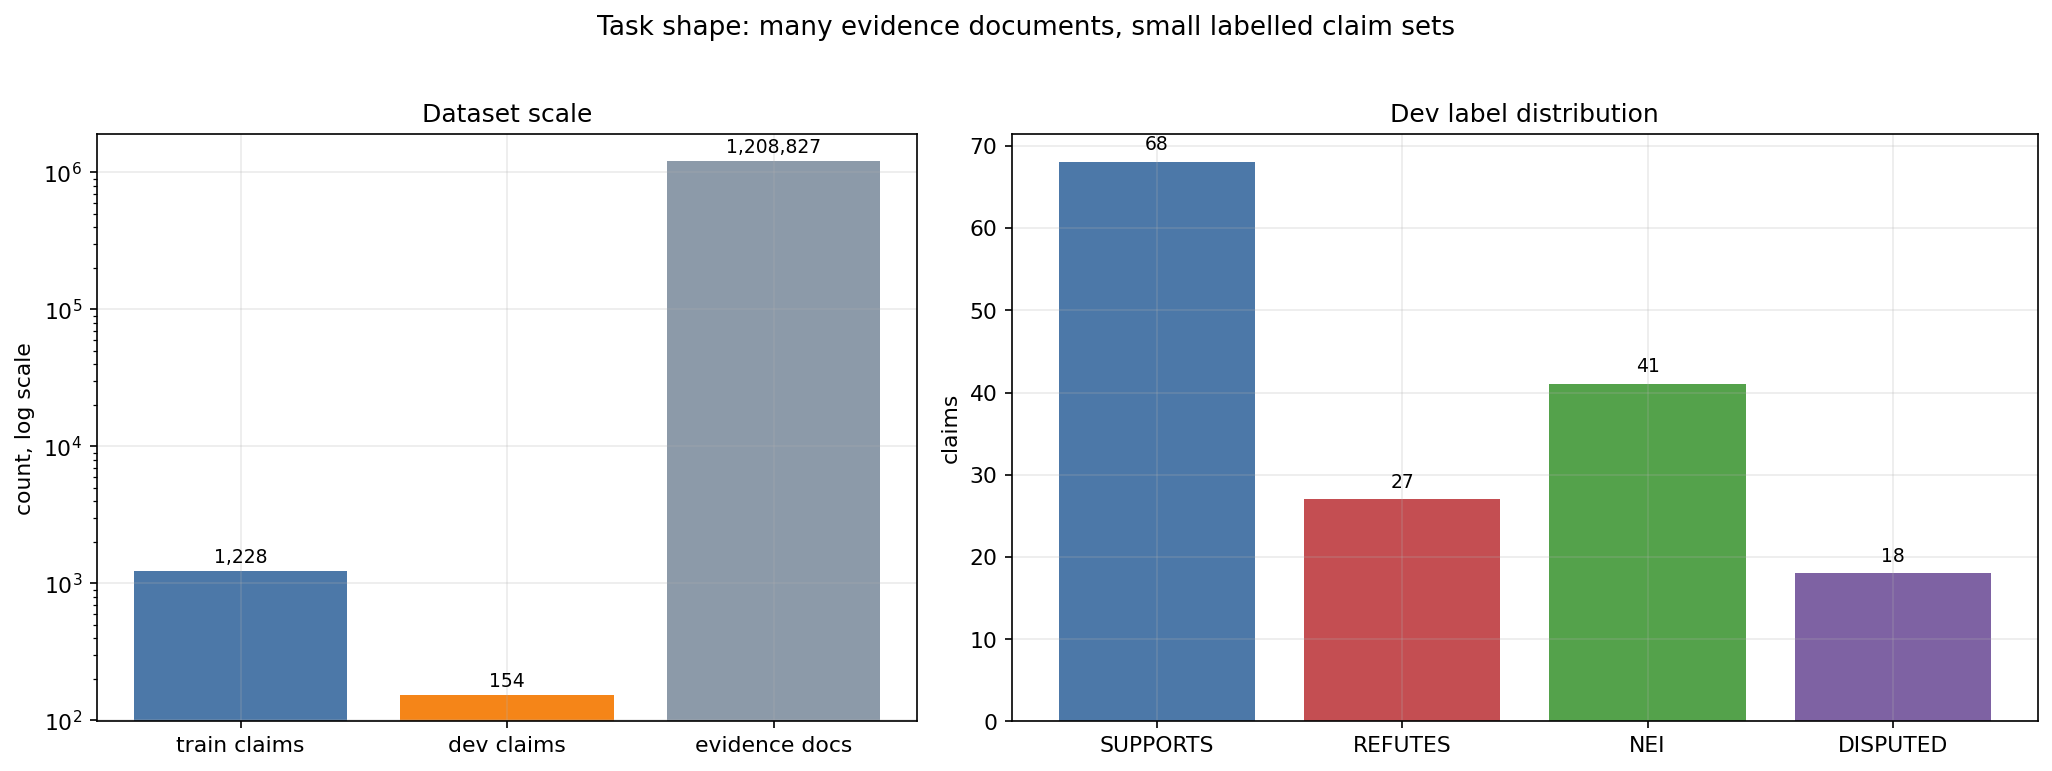

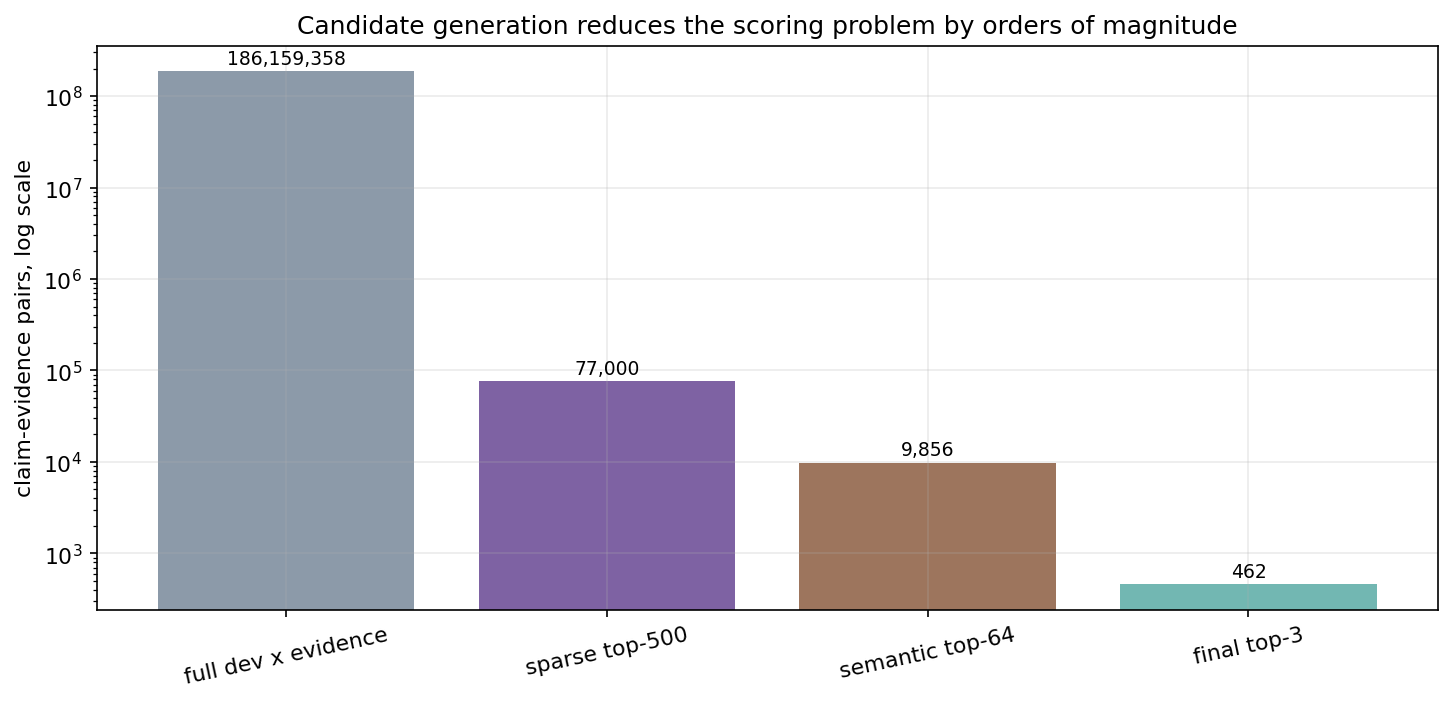

In [3]:
label_counts = Counter(claim['claim_label'] for claim in dev_claims.values())
pair_rows = [
    ('full dev x evidence', len(dev_claims) * len(evidence)),
    ('sparse top-500', len(dev_claims) * 500),
    ('semantic top-64', len(dev_claims) * 64),
    ('final top-3', len(dev_claims) * 3),
]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13.8, 5.0), gridspec_kw={'width_ratios': [1.0, 1.25]})

ax0.bar(['train claims', 'dev claims', 'evidence docs'], [len(train_claims), len(dev_claims), len(evidence)],
        color=[COLORS['blue'], COLORS['orange'], COLORS['gray']])
ax0.set_yscale('log')
ax0.set_title('Dataset scale')
ax0.set_ylabel('count, log scale')
for idx, value in enumerate([len(train_claims), len(dev_claims), len(evidence)]):
    ax0.text(idx, value * 1.08, f'{value:,}', ha='center', va='bottom', fontsize=9)

labels = [LABEL_DISPLAY[x] for x in LABEL_ORDER]
vals = [label_counts.get(x, 0) for x in LABEL_ORDER]
ax1.bar(labels, vals, color=[LABEL_COLORS[x] for x in LABEL_ORDER])
ax1.set_title('Dev label distribution')
ax1.set_ylabel('claims')
for idx, value in enumerate(vals):
    ax1.text(idx, value + 1, str(value), ha='center', va='bottom', fontsize=9)
fig.suptitle('Task shape: many evidence documents, small labelled claim sets', y=1.02)
fig.tight_layout()
savefig('round18_revised_dataset_and_labels.png')
plt.show()

fig, ax = plt.subplots(figsize=(9.8, 4.8))
cost_labels = [name for name, _ in pair_rows]
cost_vals = [value for _, value in pair_rows]
ax.bar(cost_labels, cost_vals, color=[COLORS['gray'], method_color('Fixed score-fusion gate'), method_color('Top-64 semantic reranker'), method_color('Sparse + semantic fusion')])
ax.set_yscale('log')
ax.set_ylabel('claim-evidence pairs, log scale')
ax.set_title('Candidate generation reduces the scoring problem by orders of magnitude')
ax.tick_params(axis='x', rotation=12)
for idx, value in enumerate(cost_vals):
    ax.text(idx, value * 1.08, f'{value:,}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
savefig('round18_revised_candidate_cost_bar.png')
plt.show()


# 4. Sparse Gates And Two Fusion Routes

First we compare the leaf gates by themselves. Then we test two ways to combine multiple gates.

**Score fusion** assigns fixed weights to the leaf gates and produces one ranked list. It keeps the candidate budget controlled from the start.

**Candidate union** first takes candidates from several gates and removes duplicates. This can recover evidence that only one gate sees, but it creates a larger and noisier pool, so it may need a cheap ranking step before the final top-500 cutoff.

R-n curves are appropriate here because the question is functional: how much recall is recovered as we keep more candidates?


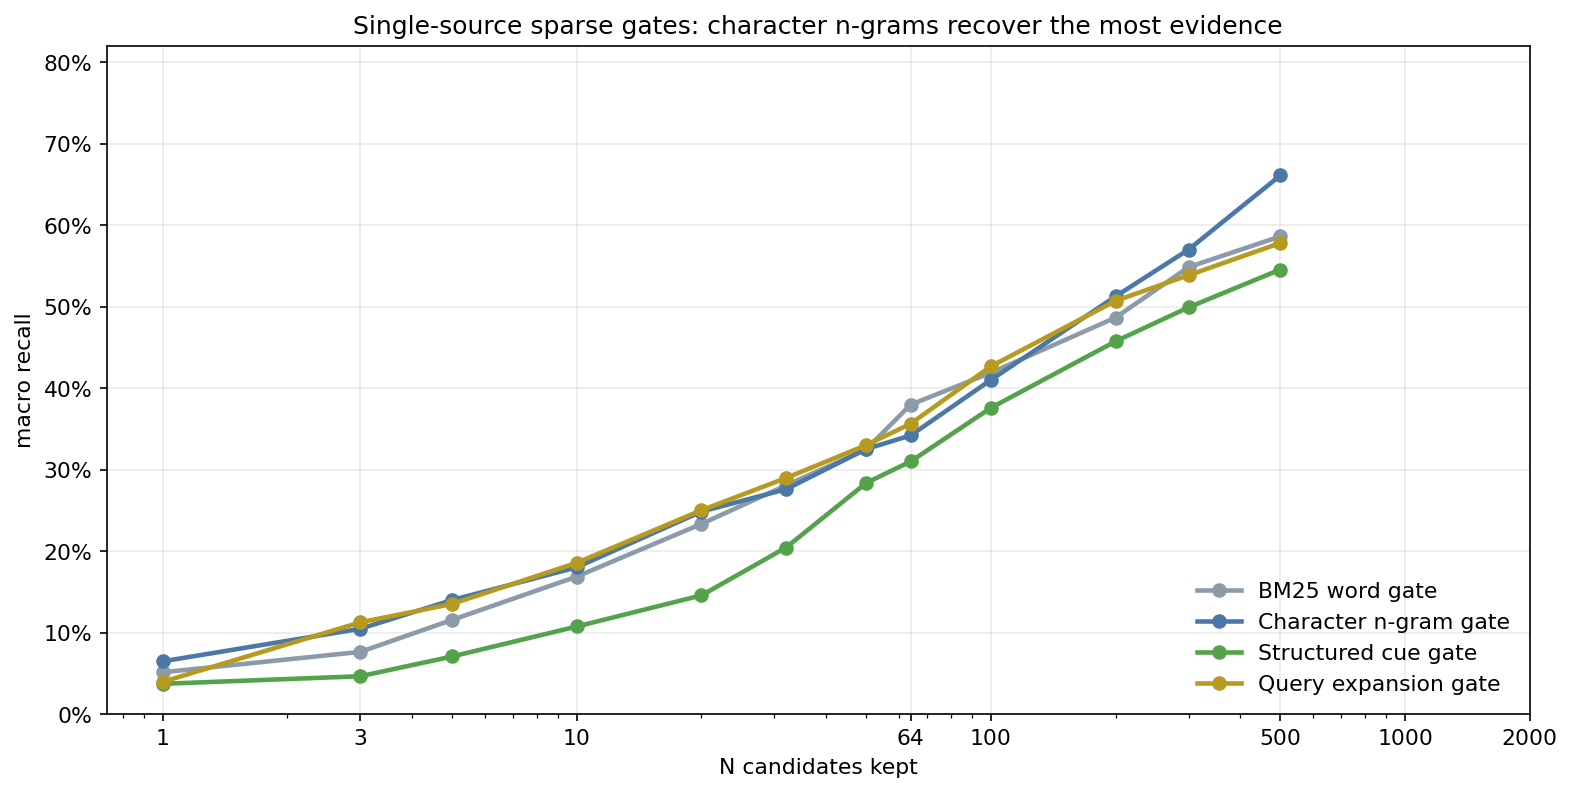

In [4]:
CANDIDATES = {
    'BM25 word gate': 'round18/outputs/o_sparse/o_s1_lexical_index_experiments/dev_full_bm25_dev_bm25_top500_candidates.json',
    'Character n-gram gate': 'round18/outputs/o_sparse/o_s6_char_tfidf/dev_full_dev_o_s6_char_tfidf_tfidf_char_top500_candidates.json',
    'Structured cue gate': 'round18/outputs/o_sparse/o_s2_structured/dev_full_dev_decomposed_candidates.json',
    'Query expansion gate': 'round18/outputs/o_sparse/o_s3_prf/candidate_pool_prf_top500.json',
    'Fixed score-fusion gate': 'round18/outputs/o_sparse/o_s7_plain_leaf_fusion/dev_full_dev_o_s7_plain_leaf_fusion_strict_rrf_char_heavy_top500_candidates.json',
    'Hand-feature reranker': 'round18/outputs/o_sparse/o_s8_hand_feature_ranker/dev_full_dev_o_s8_hand_feature_ranker_top500_candidates.json',
    'Word+character union pool': 'round18/outputs/o_sparse/o_s9_union_gate_bm25_char_dev/dev_full_dev_o_s9_union_gate_bm25_char_rrf_top1000_candidates.json',
    'Word+character candidate gate': 'round18/outputs/o_sparse/o_s9_union_gate_bm25_char_dev/dev_full_dev_o_s9_union_gate_bm25_char_rrf_top1000_candidates.json',
    'Four-gate union pool': 'round18/outputs/o_sparse/o_s9_union_gate_four_source_wide_dev/dev_full_dev_o_s9_union_gate_four_source_wide_rrf_top2000_candidates.json',
    'Union pool + cheap ranker': 'round18/outputs/o_sparse/o_s10_wide_hand_feature_bm25_char_round_robin_top1000/dev_full_dev_o_s10_wide_hand_feature_bm25_char_round_robin_top1000_top500_candidates.json',
    'Sparse baseline': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8/dev_full_dev_o_a2c_plain_leaf_rank_s8_strict_sparse_only_top500_candidates.json',
    'Top-64 semantic reranker': 'round18/outputs/o_dense/o_d3b_cross_encoder_s7/dev_full_dev_full_dev_top64_s7_strict_top64_candidates.json',
    'CE after hand-feature top64': 'round18/outputs/o_dense/o_d3x_cross_encoder_s8_diag/dev_full_dev_full_dev_top64_s8_diag_strict_top64_candidates.json',
    'CE after union+cheap top64': 'round18/outputs/o_dense/o_d3x_cross_encoder_s10_diag/dev_full_dev_full_dev_top64_s10_diag_strict_top64_candidates.json',
    'Hand-feature + full-pool CE': 'round18/outputs/o_dense/o_d3x_cross_encoder_s8_top500_diag/dev_full_dev_full_dev_top500_s8_diag_strict_top500_candidates.json',
    'Same-family CE-only selector': 'round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/dev_full_dev_o_d3x_bm25_char_dev_top500_strict_top500_candidates.json',
    'MiniLM cross-encoder selector': 'round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/dev_full_dev_o_d3x_bm25_char_dev_top500_strict_top500_candidates.json',
    'Embedding inner-product selector': 'round18/outputs/o_dense/o_d1x_embedding_bm25_char_dev_top500/dev_full_dev_o_d1x_embedding_bm25_char_dev_top500_strict_top500_candidates.json',
    'CE plus factual shallow features': 'round18/reports/ce_shallow_feature_kfold/ce_shallow_feature_kfold_best_dev_top500_candidates.json',
    'Embedding + shallow feature ranker': 'round18/reports/embedding_shallow_feature_kfold/embedding_shallow_feature_kfold_best_dev_top500_candidates.json',
    'Top-3 submission blend': 'round18/reports/top3_score_fusion_spark/top3_score_fusion_best_dev_full_dev_o_s8_hand_feature_ranker_top500_candidates_min_source_rank_ce0.75_top500_candidates.json',
    'CE plus original-rank prior': 'round18/outputs/o_rerank/top3_fusion_grid/dev_top3_fusion_grid_diagnostic_best_candidates.json',
    'Diversity control diagnostic': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8_top3_top10_mmr/dev_full_dev_o_a2c_plain_leaf_rank_s8_top3_top10_mmr_strict_rrf_sparse_ce_mmr_top3_top500_candidates.json',
    'Sparse + semantic fusion': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8/dev_full_dev_o_a2c_plain_leaf_rank_s8_strict_rrf_sparse_ce_top500_candidates.json',
}

ranked = {name: ranked_ids(path) for name, path in CANDIDATES.items() if (ROOT / path).exists()}
curves = {name: recall_curve(dev_claims, pool) for name, pool in ranked.items()}

fig, ax = plt.subplots(figsize=(10.6, 5.4))
for name in ['BM25 word gate', 'Character n-gram gate', 'Structured cue gate', 'Query expansion gate']:
    curve = curves[name]
    ax.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.2, label=name, color=method_color(name))
style_rn_axis(ax)
ax.set_title('Single-source sparse gates: character n-grams recover the most evidence')
ax.legend(loc='lower right')
fig.tight_layout()
savefig('round18_revised_single_sparse_rn.png')
plt.show()


## 4.1 Score-Based Fusion

Score fusion combines the leaf-gate ranks with fixed source weights. The weights are a categorical configuration, so they are shown as a bar chart. The retrieval effect is shown as an R-n curve. Dev-selected weights are excluded from this tutorial because they tune the candidate gate on the evaluation labels.


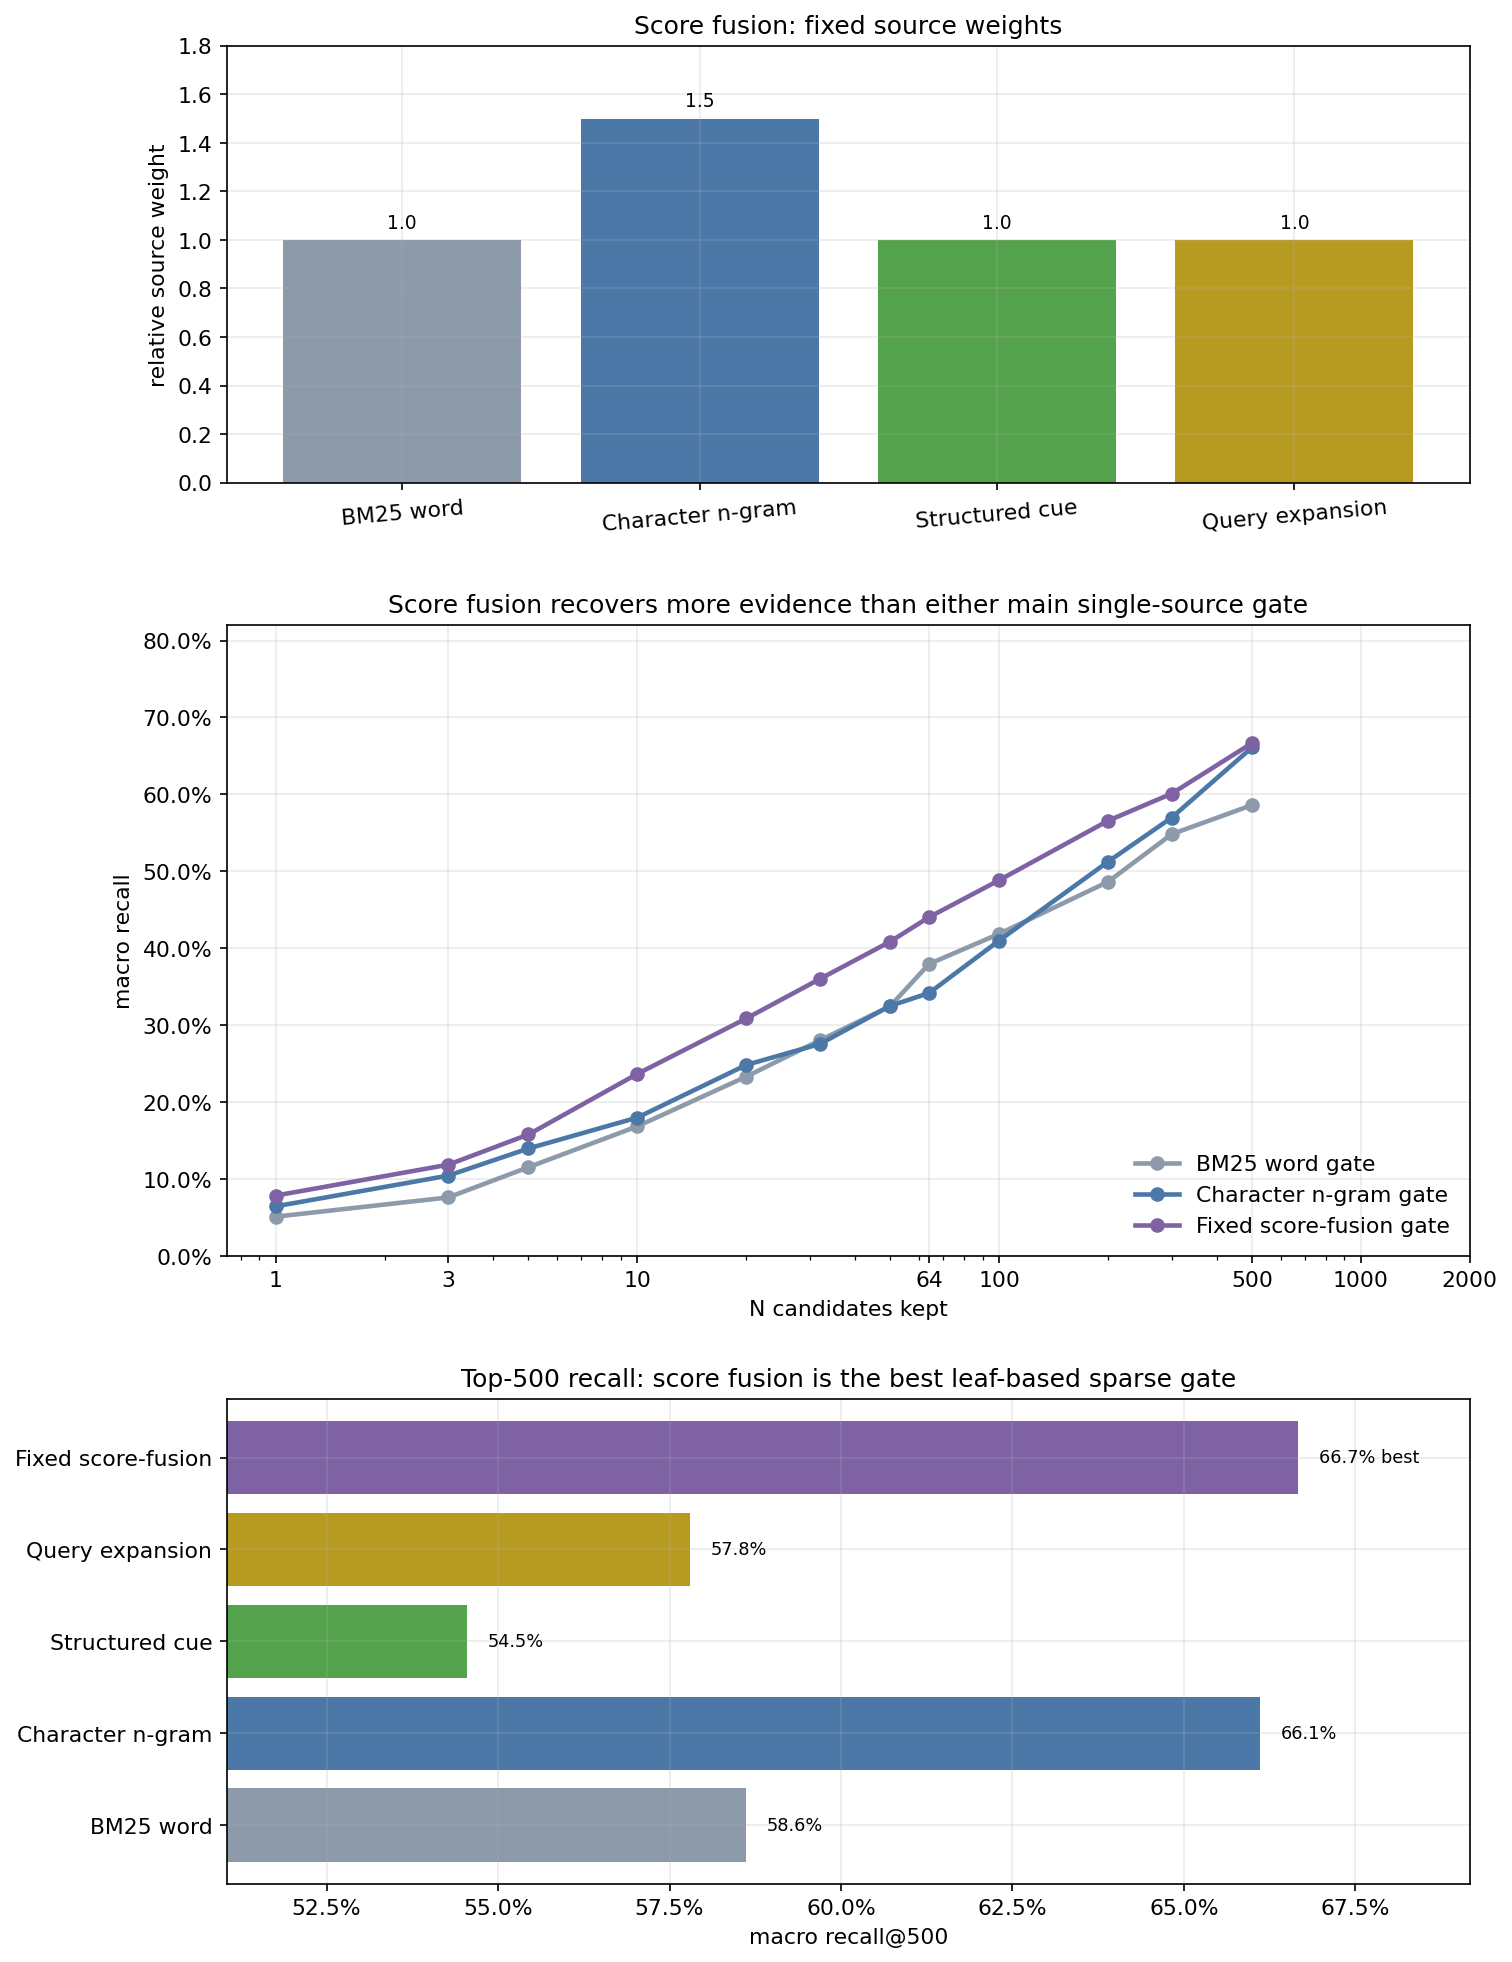

In [5]:
SPARSE_SOURCE_WEIGHTS = {
    'BM25 word gate': 1.0,
    'Character n-gram gate': 1.5,
    'Structured cue gate': 1.0,
    'Query expansion gate': 1.0,
}
fig, (ax0, ax1, ax2) = plt.subplots(
    3,
    1,
    figsize=(10.2, 13.2),
    gridspec_kw={'height_ratios': [0.9, 1.3, 1.0]},
)

weight_names = list(SPARSE_SOURCE_WEIGHTS)
weight_labels = ['BM25 word', 'Character n-gram', 'Structured cue', 'Query expansion']
ax0.bar(weight_labels, list(SPARSE_SOURCE_WEIGHTS.values()),
        color=[method_color(name) for name in SPARSE_SOURCE_WEIGHTS])
ax0.set_ylim(0, 1.8)
ax0.set_ylabel('relative source weight')
ax0.set_title('Score fusion: fixed source weights')
ax0.tick_params(axis='x', rotation=5)
for idx, value in enumerate(SPARSE_SOURCE_WEIGHTS.values()):
    ax0.text(idx, value + 0.05, f'{value:.1f}', ha='center', fontsize=9)

for name in ['BM25 word gate', 'Character n-gram gate', 'Fixed score-fusion gate']:
    curve = curves[name]
    ax1.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.2, label=name, color=method_color(name))
style_rn_axis(ax1)
ax1.set_title('Score fusion recovers more evidence than either main single-source gate')
ax1.legend(loc='lower right')

top500_names = [
    'BM25 word gate',
    'Character n-gram gate',
    'Structured cue gate',
    'Query expansion gate',
    'Fixed score-fusion gate',
]
top500_vals = [value_at(curves[name], 500) for name in top500_names]
y = np.arange(len(top500_names))
ax2.barh(
    [name.replace(' gate', '') for name in top500_names],
    top500_vals,
    color=[method_color(name) for name in top500_names],
)
ax2.xaxis.set_major_formatter(PERCENT)
ax2.set_xlim(max(0.0, min(top500_vals) - 0.035), min(1.0, max(top500_vals) + 0.025))
ax2.set_xlabel('macro recall@500')
ax2.set_title('Top-500 recall: score fusion is the best leaf-based sparse gate')
best_idx = int(np.argmax(top500_vals))
for idx, value in enumerate(top500_vals):
    label = f'{value:.1%}'
    if idx == best_idx:
        label += ' best'
    ax2.text(value + 0.003, idx, label, va='center', fontsize=8.5)
fig.tight_layout(h_pad=2.2)
savefig('round18_revised_sparse_fusion_weights_and_rn.png')
plt.show()


## 4.2 Candidate-Union Fusion

Candidate union is the second way to combine gates. Instead of giving each source a weight and producing one score, we first take the top candidates from several sources, deduplicate them, and keep a larger pool ordered by a simple source-rank rule. The last variant adds a cheap hand-feature ranker to compress that larger union back to a final top-500.

This section is diagnostic rather than the final decision: it shows why union can help coverage, and why the union pool becomes a cost question once it needs an extra ranker.


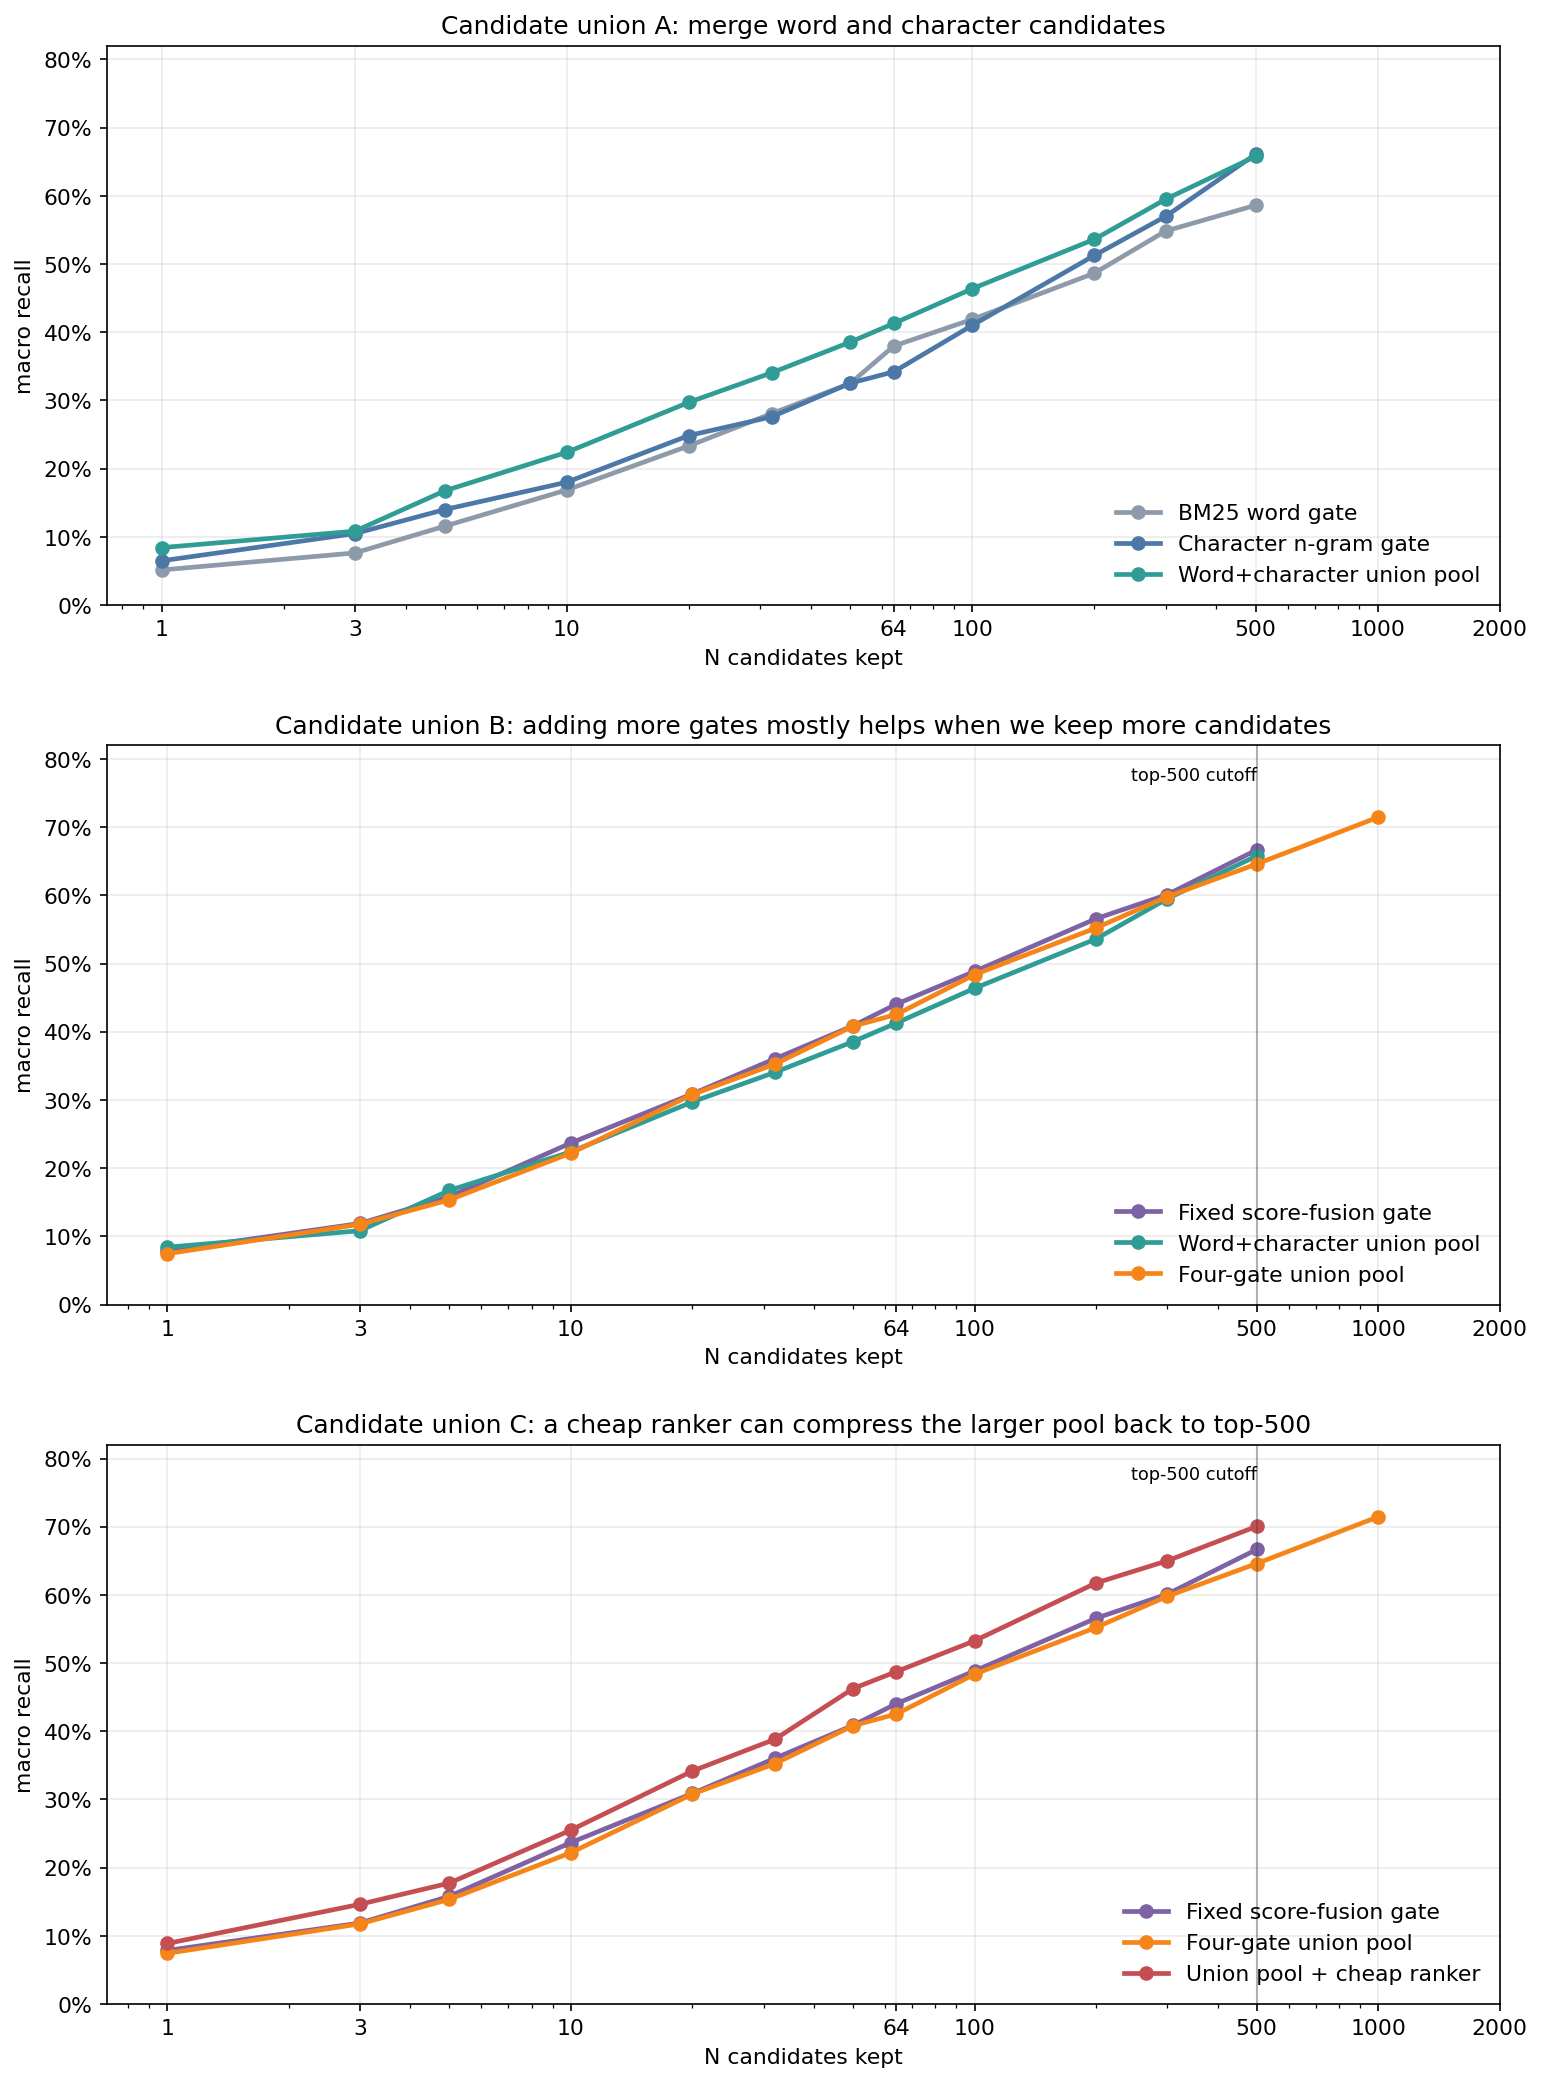

In [6]:
fig, (ax0, ax1, ax2) = plt.subplots(
    3,
    1,
    figsize=(10.4, 14.0),
    gridspec_kw={'height_ratios': [1.0, 1.0, 1.0]},
)

for name in ['BM25 word gate', 'Character n-gram gate', 'Word+character union pool']:
    curve = curves[name]
    ax0.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax0)
ax0.set_title('Candidate union A: merge word and character candidates')
ax0.legend(loc='lower right')

for name in ['Fixed score-fusion gate', 'Word+character union pool', 'Four-gate union pool']:
    curve = curves[name]
    ax1.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax1)
ax1.set_title('Candidate union B: adding more gates mostly helps when we keep more candidates')
ax1.legend(loc='lower right')
ax1.axvline(500, color='#333333', lw=1.0, alpha=0.32)
ax1.text(500, 0.79, 'top-500 cutoff', va='top', ha='right', fontsize=8.5)

for name in ['Fixed score-fusion gate', 'Four-gate union pool', 'Union pool + cheap ranker']:
    curve = curves[name]
    ax2.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax2)
ax2.set_title('Candidate union C: a cheap ranker can compress the larger pool back to top-500')
ax2.legend(loc='lower right')
ax2.axvline(500, color='#333333', lw=1.0, alpha=0.32)
ax2.text(500, 0.79, 'top-500 cutoff', va='top', ha='right', fontsize=8.5)

fig.tight_layout(h_pad=2.1)
savefig('round18_revised_union_strategy_rn.png')
plt.show()


# 5. Why The Final Top-500 Uses Score Fusion

The union route proves that larger candidate pools can recover extra evidence, but the useful union result needs an additional cheap ranker. Once we include runtime, the top-500 choice is no longer just "which recall is highest"; it is "which recall gain is worth the extra cost." The final strict top-500 gate therefore uses fixed score fusion.


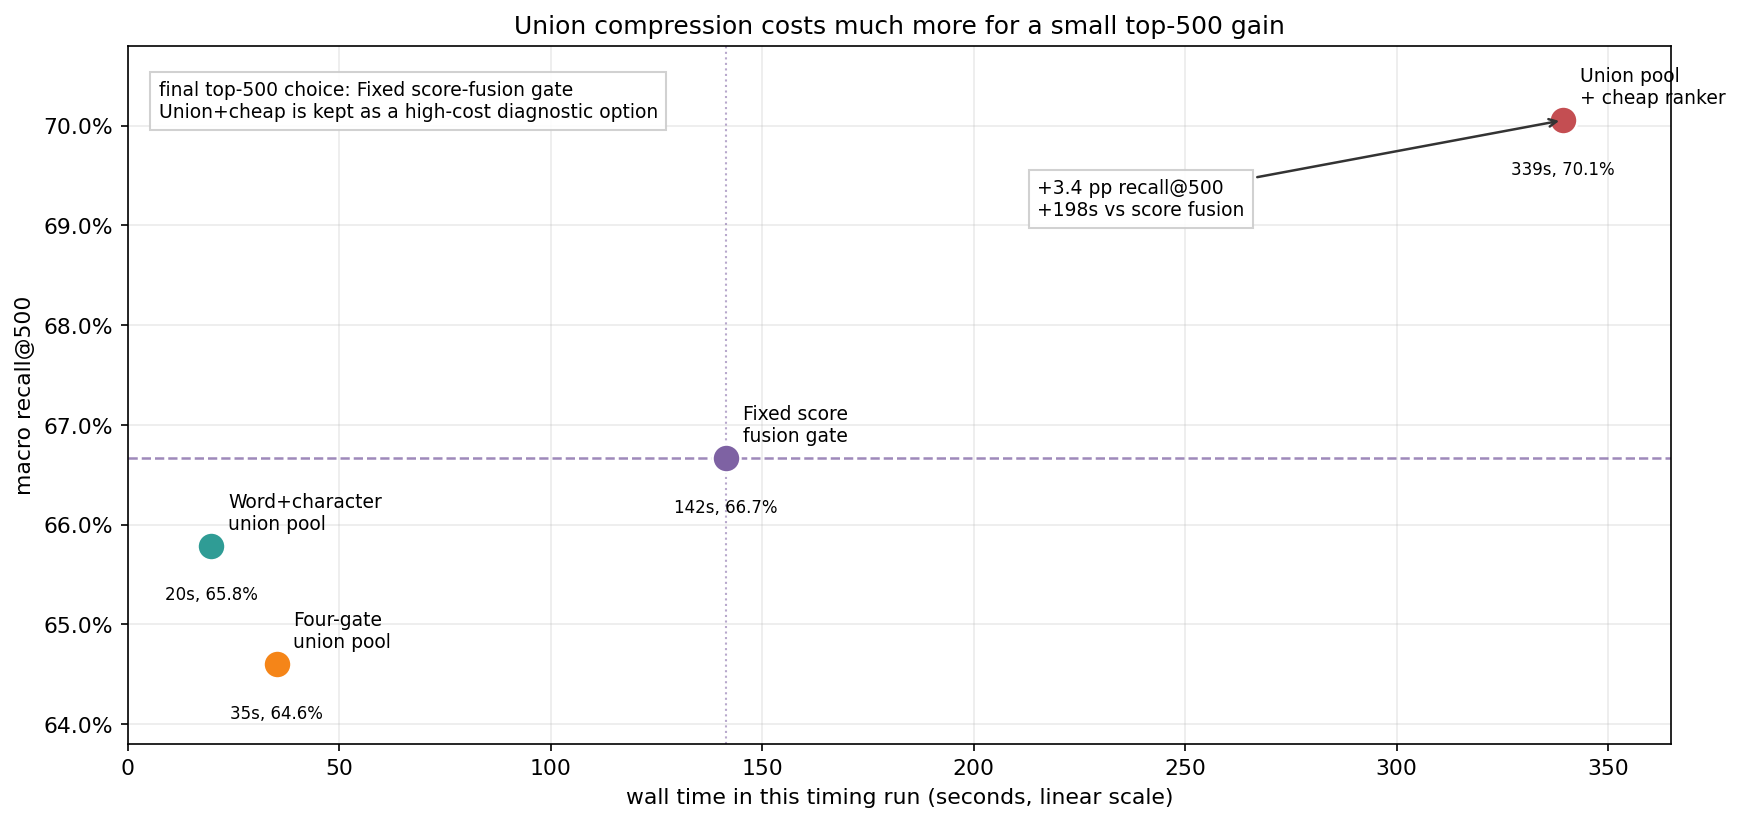

In [7]:
tradeoff_rows = [
    {
        'name': 'Fixed score-fusion gate',
        'seconds': manifest_seconds('round18/outputs/o_sparse/o_s7_plain_leaf_fusion/run_manifest.json'),
        'recall500': value_at(curves['Fixed score-fusion gate'], 500),
    },
    {
        'name': 'Word+character union pool',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s9_bm25_char_dev/run_manifest.json'),
        'recall500': value_at(curves['Word+character union pool'], 500),
    },
    {
        'name': 'Four-gate union pool',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s9_four_source_wide_dev/run_manifest.json'),
        'recall500': value_at(curves['Four-gate union pool'], 500),
    },
    {
        'name': 'Union pool + cheap ranker',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s10_bm25_char_round_robin_top1000/run_manifest.json'),
        'recall500': value_at(curves['Union pool + cheap ranker'], 500),
    },
]
baseline = tradeoff_rows[0]
display_names = ['Fixed score\nfusion gate', 'Word+character\nunion pool', 'Four-gate\nunion pool', 'Union pool\n+ cheap ranker']

fig, ax = plt.subplots(figsize=(11.8, 5.6))
for row, label in zip(tradeoff_rows, display_names):
    ax.scatter(
        row['seconds'],
        row['recall500'],
        s=180,
        color=method_color(row['name']),
        edgecolor='white',
        linewidth=1.2,
        zorder=3,
    )
    ax.annotate(
        label,
        (row['seconds'], row['recall500']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
    )
ax.axhline(baseline['recall500'], color=method_color('Fixed score-fusion gate'), ls='--', lw=1.2, alpha=0.75)
ax.axvline(baseline['seconds'], color=method_color('Fixed score-fusion gate'), ls=':', lw=1.0, alpha=0.55)
ax.set_xlim(0, 365)
ax.set_ylim(0.638, 0.708)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel('wall time in this timing run (seconds, linear scale)')
ax.set_ylabel('macro recall@500')
ax.set_title('Union compression costs much more for a small top-500 gain')
for row in tradeoff_rows:
    ax.text(
        row['seconds'],
        row['recall500'] - 0.004,
        f"{row['seconds']:.0f}s, {row['recall500']:.1%}",
        ha='center',
        va='top',
        fontsize=8,
    )
union_ranked = tradeoff_rows[-1]
ax.annotate(
    f"+{(union_ranked['recall500'] - baseline['recall500']) * 100:.1f} pp recall@500\n+{union_ranked['seconds'] - baseline['seconds']:.0f}s vs score fusion",
    xy=(union_ranked['seconds'], union_ranked['recall500']),
    xytext=(215, 0.691),
    arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '#333333'},
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
ax.text(
    0.02,
    0.95,
    'final top-500 choice: Fixed score-fusion gate\nUnion+cheap is kept as a high-cost diagnostic option',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_union_cost_benefit.png')
plt.show()


# 6. Top-64 Context Selection

The first top-64 question is a membership question: after the same word+character candidate gate has produced a fixed top-500 pool, which selector puts the gold evidence inside the first 64 context slots?

We compare four selectors on that same candidate family: direct cutoff, a learned shallow-feature selector, MiniLM embedding inner product, and a MiniLM cross-encoder. This keeps the top-64 story separate from the final top-3 evidence ordering story.


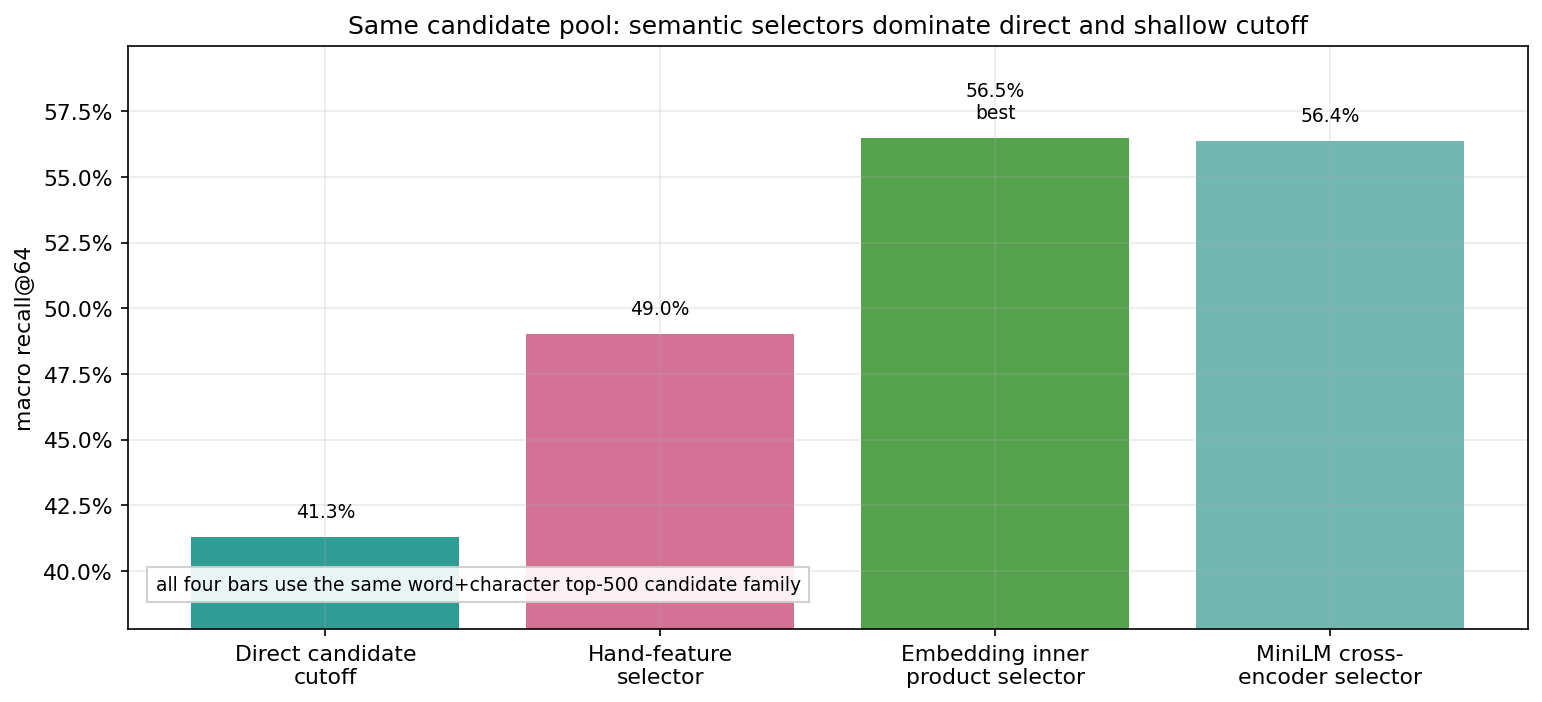

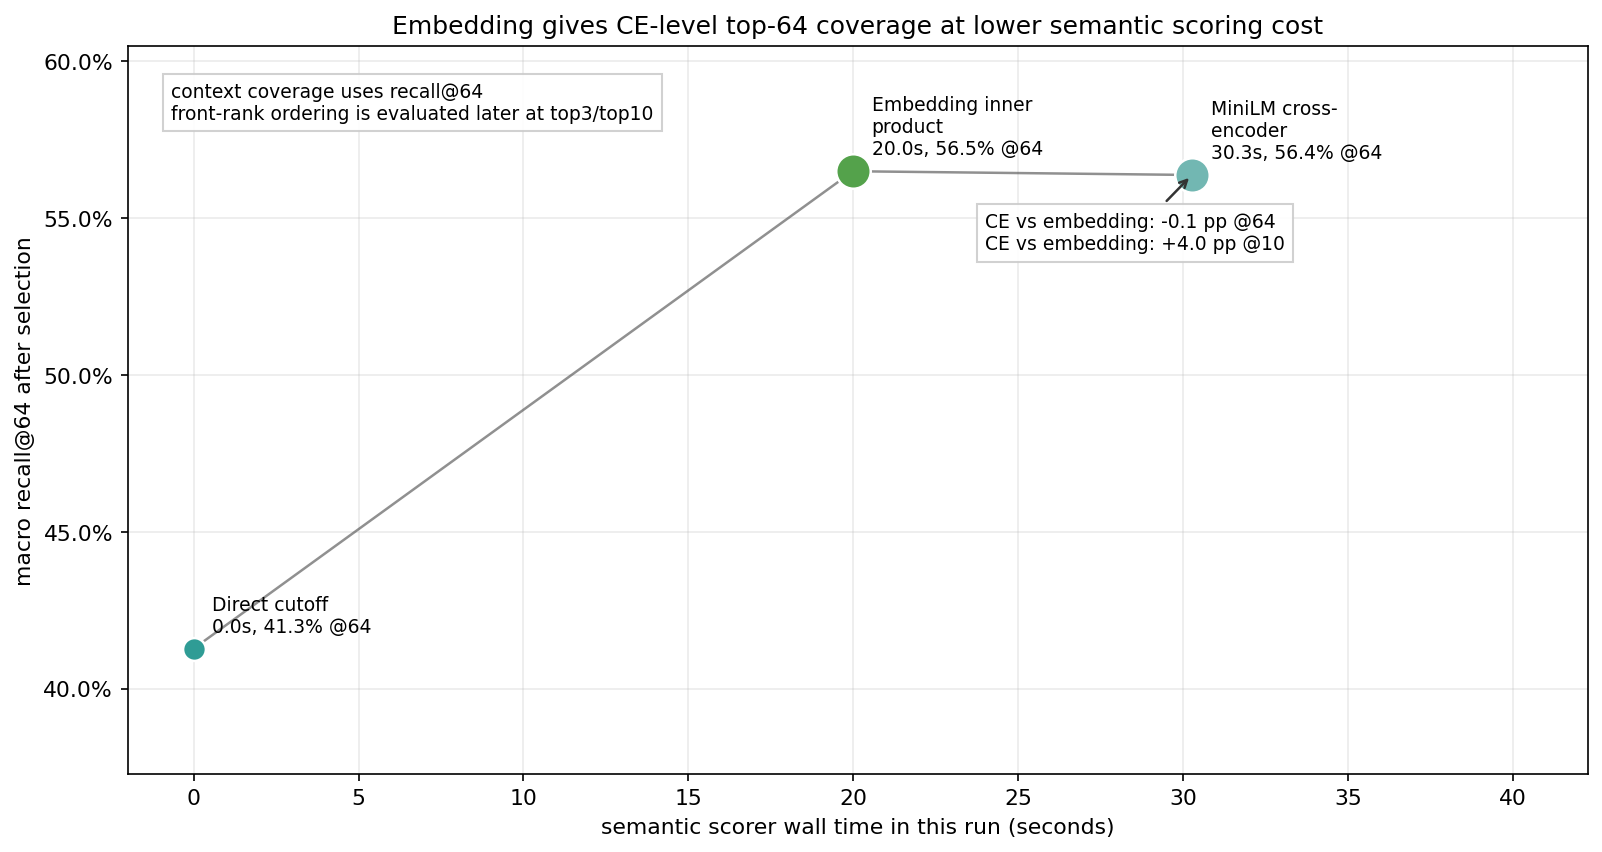

In [8]:
embedding_shallow_summary = load_json('round18/reports/embedding_shallow_feature_kfold/embedding_shallow_feature_kfold_summary.json')
embedding_shallow_rows = {row['variant']: row for row in embedding_shallow_summary['rows']}

top64_same_source = [
    {
        'label': 'Direct candidate\ncutoff',
        'name': 'Word+character candidate gate',
        'value': value_at(curves['Word+character candidate gate'], 64),
        'note': 'no learned selector',
    },
    {
        'label': 'Hand-feature\nselector',
        'name': 'Hand-feature selector on same candidates',
        'value': metric_at(embedding_shallow_rows['shallow_only'], 64),
        'note': 'train k-fold shallow ranker',
    },
    {
        'label': 'Embedding inner\nproduct selector',
        'name': 'Embedding inner-product selector',
        'value': value_at(curves['Embedding inner-product selector'], 64),
        'note': 'MiniLM bi-encoder',
    },
    {
        'label': 'MiniLM cross-\nencoder selector',
        'name': 'MiniLM cross-encoder selector',
        'value': value_at(curves['MiniLM cross-encoder selector'], 64),
        'note': 'pairwise MiniLM/CE',
    },
]
vals = [row['value'] for row in top64_same_source]
x = np.arange(len(top64_same_source))
fig, ax = plt.subplots(figsize=(10.4, 4.8))
ax.bar(x, vals, color=[method_color(row['name']) for row in top64_same_source])
for xpos, value in zip(x, vals):
    label = f'{value:.1%}'
    if value == max(finite(vals)):
        label += '\nbest'
    ax.text(xpos, value + 0.006, label, ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([row['label'] for row in top64_same_source])
ax.yaxis.set_major_formatter(PERCENT)
percent_ylim(ax, vals, pad=0.035, floor=0.35, ceiling=0.64)
ax.set_ylabel('macro recall@64')
ax.set_title('Same candidate pool: semantic selectors dominate direct and shallow cutoff')
ax.text(
    0.02,
    0.06,
    'all four bars use the same word+character top-500 candidate family',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_top64_compression_selector_bar.png')
plt.show()

semantic_budget_rows = [
    {
        'label': 'Direct cutoff',
        'key': 'Word+character candidate gate',
        'seconds': 0.0,
        'pairs': 0,
    },
    {
        'label': 'Embedding inner\nproduct',
        'key': 'Embedding inner-product selector',
        'seconds': manifest_seconds('round18/outputs/o_dense/o_d1x_embedding_bm25_char_dev_top500/run_manifest.json'),
        'pairs': len(dev_claims) * 500,
    },
    {
        'label': 'MiniLM cross-\nencoder',
        'key': 'MiniLM cross-encoder selector',
        'seconds': manifest_seconds('round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/run_manifest.json'),
        'pairs': len(dev_claims) * 500,
    },
]
for row in semantic_budget_rows:
    row['recall3'] = value_at(curves[row['key']], 3)
    row['recall10'] = value_at(curves[row['key']], 10)
    row['recall64'] = value_at(curves[row['key']], 64)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
for row in semantic_budget_rows:
    ax.scatter(
        row['seconds'],
        row['recall64'],
        s=120 + row['pairs'] / 500,
        color=method_color(row['key']),
        edgecolor='white',
        linewidth=1.2,
        zorder=3,
    )
    ax.annotate(
        f"{row['label']}\n{row['seconds']:.1f}s, {row['recall64']:.1%} @64",
        (row['seconds'], row['recall64']),
        xytext=(9, 8),
        textcoords='offset points',
        fontsize=9,
    )
direct, embed, ce = semantic_budget_rows
ax.plot(
    [direct['seconds'], embed['seconds'], ce['seconds']],
    [direct['recall64'], embed['recall64'], ce['recall64']],
    color='#555555',
    lw=1.2,
    alpha=0.65,
)
ax.annotate(
    f"CE vs embedding: {(ce['recall64'] - embed['recall64']) * 100:+.1f} pp @64\n"
    f"CE vs embedding: {(ce['recall10'] - embed['recall10']) * 100:+.1f} pp @10",
    xy=(ce['seconds'], ce['recall64']),
    xytext=(max(embed['seconds'] + 3.0, 24.0), max(embed['recall64'], ce['recall64']) - 0.025),
    arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '#333333'},
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
ax.text(
    0.03,
    0.95,
    "context coverage uses recall@64\nfront-rank ordering is evaluated later at top3/top10",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
ax.set_xlim(-2, max(row['seconds'] for row in semantic_budget_rows) + 12)
percent_ylim(ax, [row['recall64'] for row in semantic_budget_rows], pad=0.04, floor=0.35, ceiling=0.64)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel('semantic scorer wall time in this run (seconds)')
ax.set_ylabel('macro recall@64 after selection')
ax.set_title('Embedding gives CE-level top-64 coverage at lower semantic scoring cost')
fig.tight_layout()
savefig('round18_revised_ce_budget_tradeoff.png')
plt.show()


# 7. Shallow Features As Embedding Complement

The next question is whether shallow factual cues can supplement the embedding selector. The experiment is train-selected: we run claim-level k-fold CV on train, choose the feature family there, and then confirm once on dev.

This is the place to test the hypothesis that dense embeddings may miss useful surface evidence such as exact names, years, numbers, and explicit lexical overlap.


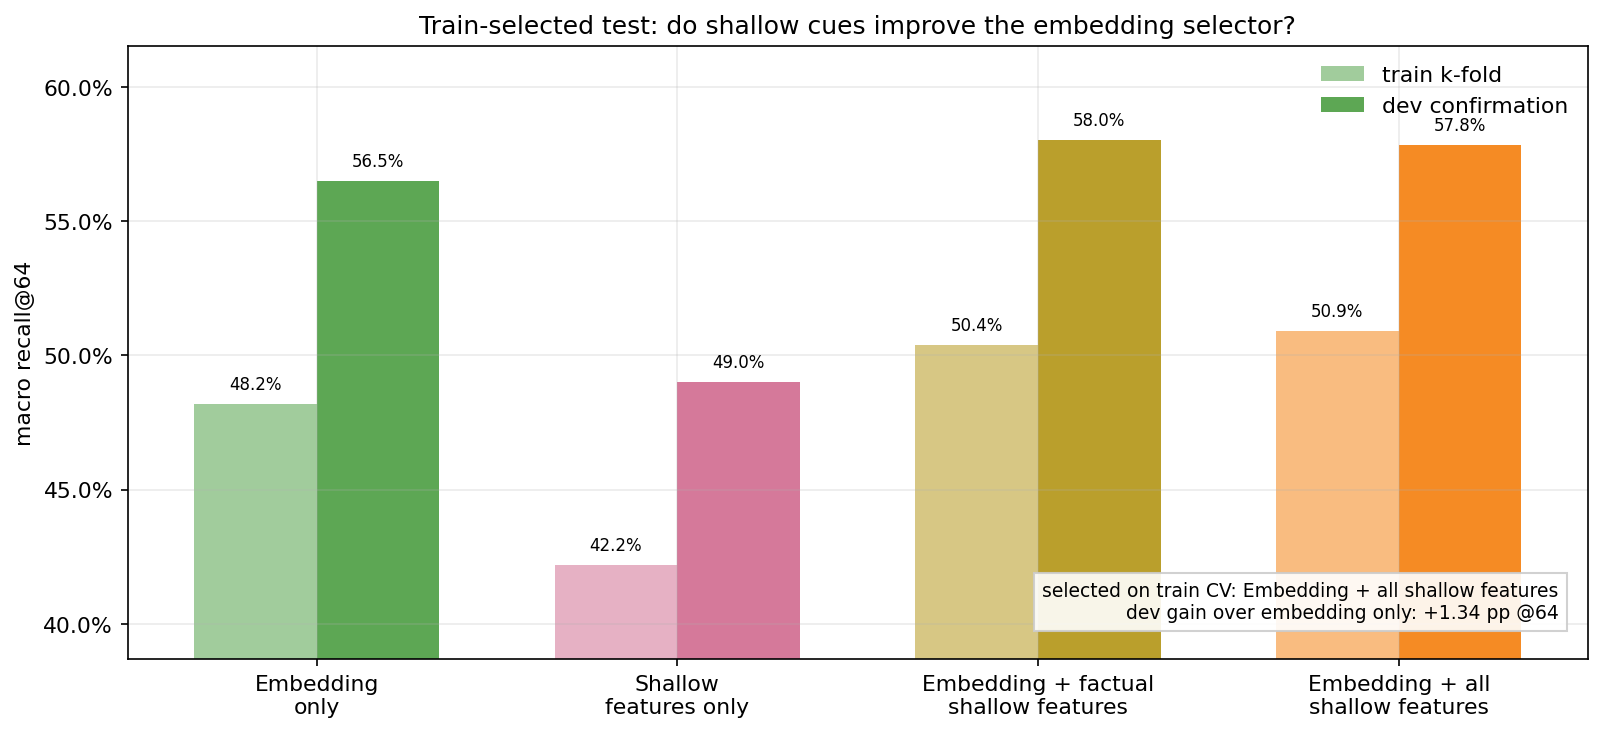

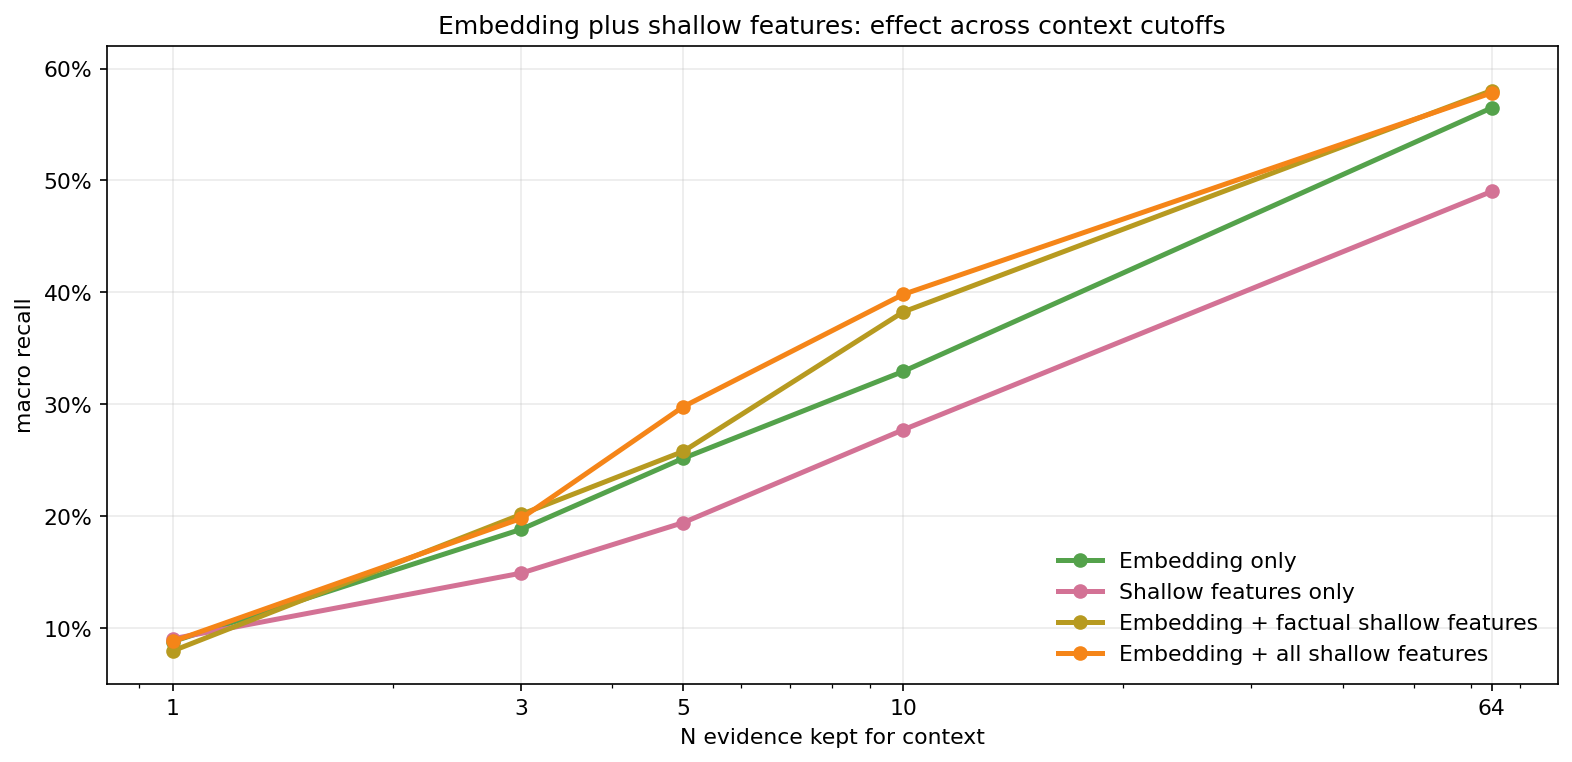

In [9]:
variant_display = {
    'embedding_only': 'Embedding\nonly',
    'shallow_only': 'Shallow\nfeatures only',
    'embedding_plus_factual': 'Embedding + factual\nshallow features',
    'embedding_plus_shallow': 'Embedding + all\nshallow features',
}
variant_colors = {
    'embedding_only': method_color('Embedding inner-product selector'),
    'shallow_only': method_color('Hand-feature reranker'),
    'embedding_plus_factual': method_color('Embedding + shallow feature ranker'),
    'embedding_plus_shallow': COLORS['orange'],
}
ordered_variants = [
    'embedding_only',
    'shallow_only',
    'embedding_plus_factual',
    'embedding_plus_shallow',
]
row_by_variant = embedding_shallow_rows
x = np.arange(len(ordered_variants))
width = 0.34
fig, ax = plt.subplots(figsize=(10.8, 5.0))
cv_vals = [row_by_variant[v]['cv_macro_recall@64'] for v in ordered_variants]
dev_vals = [row_by_variant[v]['dev_macro_recall@64'] for v in ordered_variants]
ax.bar(x - width / 2, cv_vals, width=width, color=[variant_colors[v] for v in ordered_variants], alpha=0.55, label='train k-fold')
ax.bar(x + width / 2, dev_vals, width=width, color=[variant_colors[v] for v in ordered_variants], alpha=0.95, label='dev confirmation')
for xpos, value in zip(x - width / 2, cv_vals):
    ax.text(xpos, value + 0.004, f'{value:.1%}', ha='center', va='bottom', fontsize=8)
for xpos, value in zip(x + width / 2, dev_vals):
    ax.text(xpos, value + 0.004, f'{value:.1%}', ha='center', va='bottom', fontsize=8)
selected = embedding_shallow_summary['best_variant']
embedding_only = row_by_variant['embedding_only']
selected_label = variant_display[selected['variant']].replace('\n', ' ')
ax.text(
    0.98,
    0.06,
    f"selected on train CV: {selected_label}\n"
    f"dev gain over embedding only: {(selected['dev_macro_recall@64'] - embedding_only['dev_macro_recall@64']) * 100:+.2f} pp @64",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
ax.set_xticks(x)
ax.set_xticklabels([variant_display[v] for v in ordered_variants])
ax.yaxis.set_major_formatter(PERCENT)
percent_ylim(ax, cv_vals + dev_vals, pad=0.035, floor=0.35, ceiling=0.64)
ax.set_ylabel('macro recall@64')
ax.set_title('Train-selected test: do shallow cues improve the embedding selector?')
ax.legend(loc='upper right')
fig.tight_layout()
savefig('round18_revised_embedding_shallow_kfold_bar.png')
plt.show()

fig, ax = plt.subplots(figsize=(10.6, 5.2))
shallow_k = [1, 3, 5, 10, 64]
for variant in ordered_variants:
    row = row_by_variant[variant]
    curve = [
        {'top_n': k, 'macro_recall': row[f'dev_macro_recall@{k}']}
        for k in shallow_k
        if f'dev_macro_recall@{k}' in row
    ]
    ax.plot(
        [x['top_n'] for x in curve],
        [x['macro_recall'] for x in curve],
        marker='o',
        lw=2.4,
        label=variant_display[variant].replace('\n', ' '),
        color=variant_colors[variant],
    )
ax.set_xscale('log')
ax.set_xticks(shallow_k)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}' if value >= 1 else ''))
ax.yaxis.set_major_formatter(PERCENT)
curve_values = [
    row[f'dev_macro_recall@{k}']
    for row in row_by_variant.values()
    for k in shallow_k
    if f'dev_macro_recall@{k}' in row
]
percent_ylim(ax, curve_values, pad=0.04, floor=0.05, ceiling=0.64)
ax.set_xlabel('N evidence kept for context')
ax.set_ylabel('macro recall')
ax.set_title('Embedding plus shallow features: effect across context cutoffs')
ax.legend(loc='lower right')
fig.tight_layout()
savefig('round18_revised_embedding_shallow_rn.png')
plt.show()


# 8. Top-3 Evidence For Submission

The submitted evidence list is a different operating point from classifier context. For the final evidence field, the first three items matter most, so we evaluate `recall@3` directly.

The score-blend result below is marked diagnostic because the weights were selected on dev. It is useful evidence for the design direction, but strict promotion requires the same fixed rule to be selected from train-only evidence or pre-registered before dev evaluation.


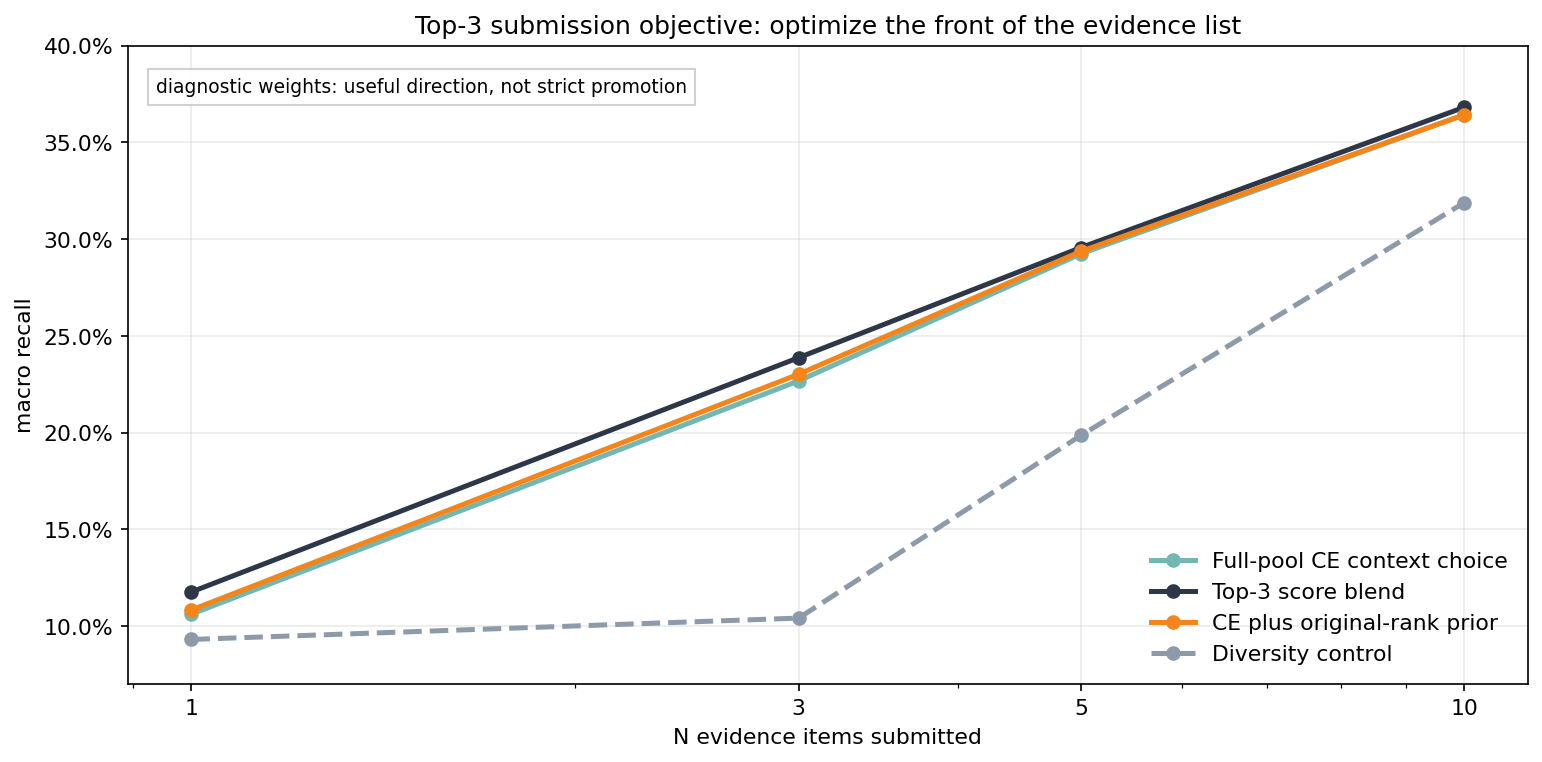

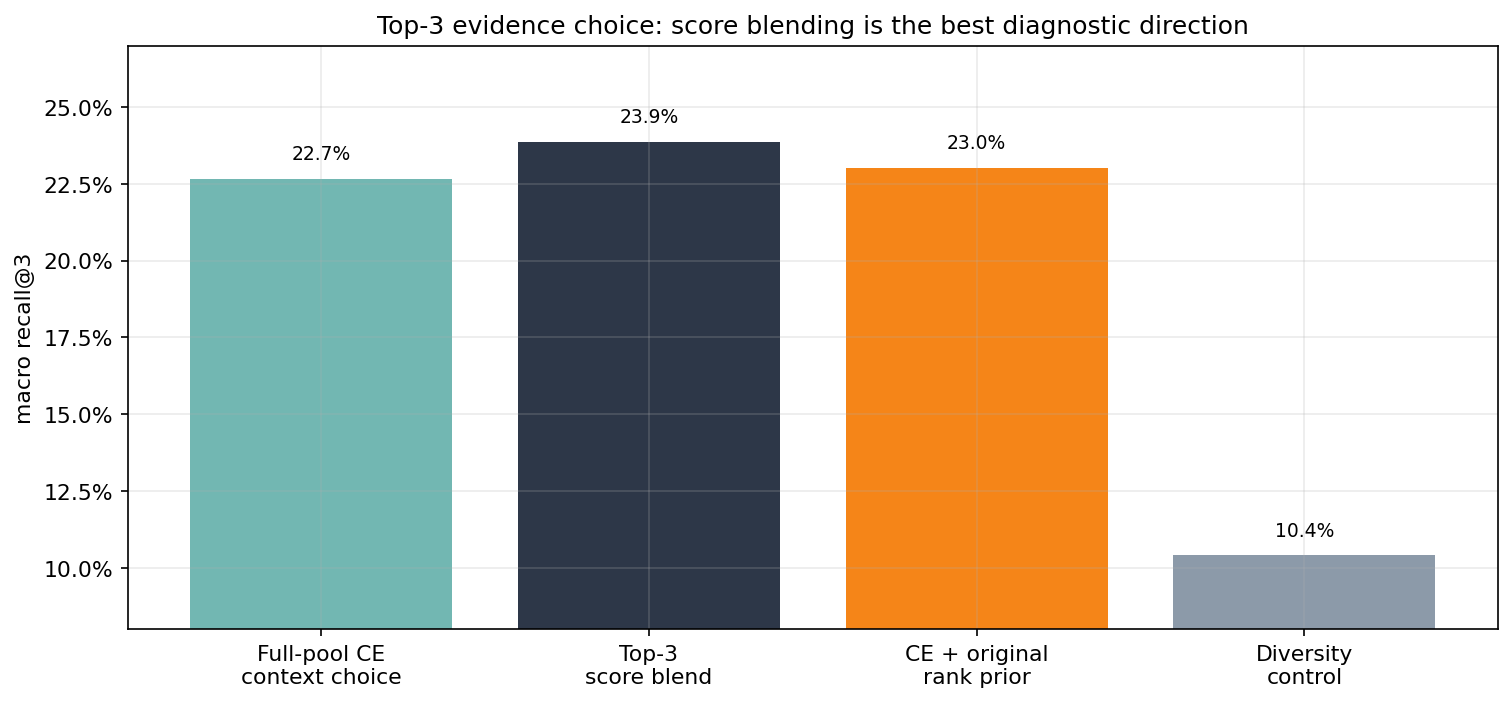

In [10]:
top3_methods = [
    ('Full-pool CE context choice', 'Hand-feature + full-pool CE'),
    ('Top-3 score blend', 'Top-3 submission blend'),
    ('CE plus original-rank prior', 'CE plus original-rank prior'),
    ('Diversity control', 'Diversity control diagnostic'),
]

fig, ax = plt.subplots(figsize=(10.4, 5.2))
for display, name in top3_methods:
    if name not in curves:
        continue
    curve = [row for row in curves[name] if row['top_n'] <= 10]
    linestyle = '--' if name == 'Diversity control diagnostic' else '-'
    ax.plot(
        [x['top_n'] for x in curve],
        [x['macro_recall'] for x in curve],
        marker='o',
        lw=2.4,
        ls=linestyle,
        label=display,
        color=method_color(name),
    )
ax.set_xscale('log')
ax.set_xticks([1, 3, 5, 10])
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}'))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylim(0.07, 0.40)
ax.set_xlabel('N evidence items submitted')
ax.set_ylabel('macro recall')
ax.set_title('Top-3 submission objective: optimize the front of the evidence list')
ax.legend(loc='lower right')
ax.text(
    0.02,
    0.95,
    'diagnostic weights: useful direction, not strict promotion',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_top3_submission_rn.png')
plt.show()

bar_methods = [
    ('Full-pool CE\ncontext choice', 'Hand-feature + full-pool CE'),
    ('Top-3\nscore blend', 'Top-3 submission blend'),
    ('CE + original\nrank prior', 'CE plus original-rank prior'),
    ('Diversity\ncontrol', 'Diversity control diagnostic'),
]
vals = [value_at(curves[name], 3) for _, name in bar_methods]
x = np.arange(len(bar_methods))
fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.bar(x, vals, color=[method_color(name) for _, name in bar_methods])
for xpos, value in zip(x, vals):
    ax.text(xpos, value + 0.005, f'{value:.1%}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in bar_methods])
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylim(0.08, 0.27)
ax.set_ylabel('macro recall@3')
ax.set_title('Top-3 evidence choice: score blending is the best diagnostic direction')
fig.tight_layout()
savefig('round18_revised_top3_submission_bar.png')
plt.show()


# 9. Classifier Recovery

The strict classifier must use the same context family for train and dev. The recovered strict classifier fixes that parity issue and rejects collapsed models. Curves are used for context depth and C-grid sweeps; final model/category comparisons are bars.


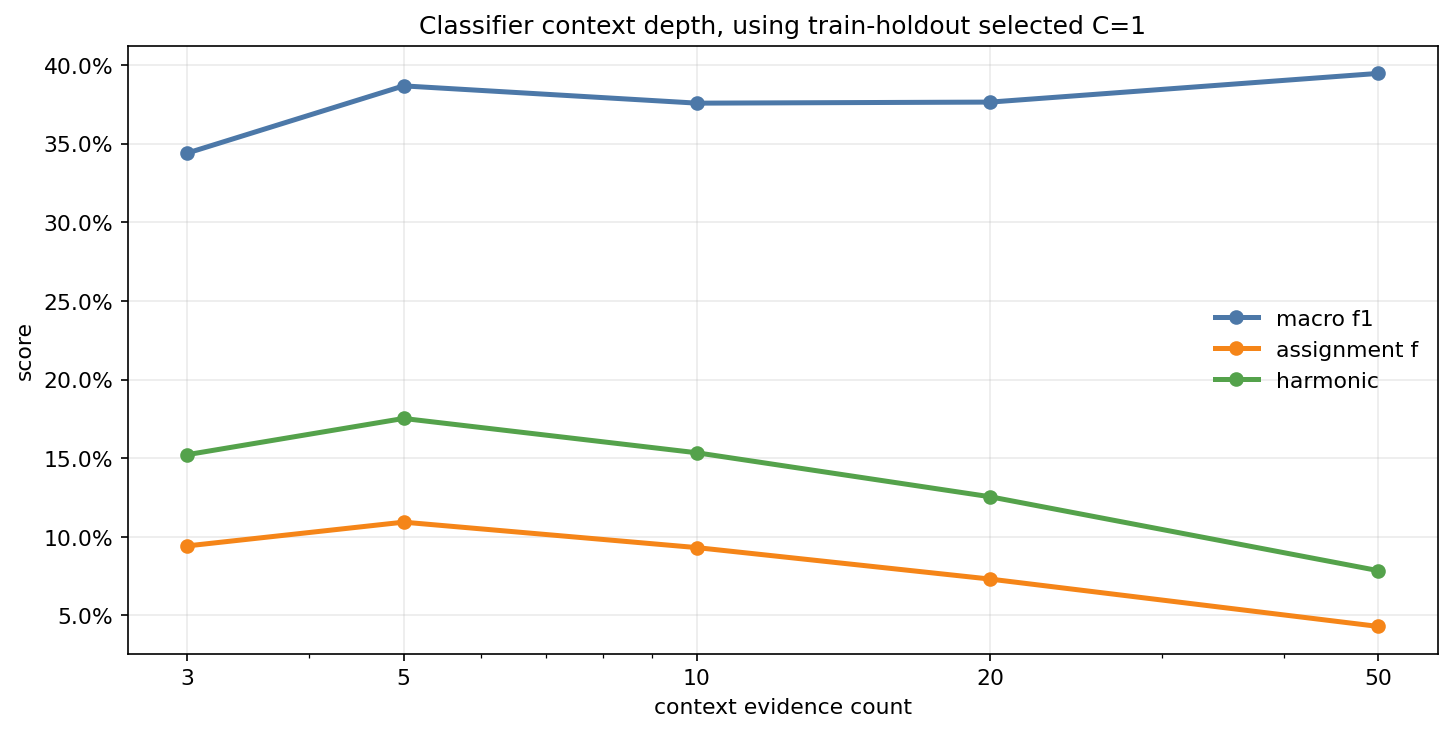

In [11]:
classifier_rows = load_csv('round18/reports/tutorial_rn_curves/tutorial_o_c3_classifier_summary.csv')

def numeric(row, key):
    value = row.get(key, '')
    return float(value) if value not in ('', None) else None

def rows_for(pattern, c_value='c1p0'):
    selected = []
    for row in classifier_rows:
        if pattern in row['run_id'] and c_value in row['selected_variant']:
            selected.append(row)
    return selected

c1_depth_rows = []
for row in classifier_rows:
    if (
        'c1p0' in row['selected_variant']
        and row['model_name'] == 'tfidf_logreg'
        and row['dev_context_k']
        and row.get('evidence_token_budget') in ('0', 0, None)
    ):
        c1_depth_rows.append({
            'k': int(row['dev_context_k']),
            'accuracy': numeric(row, 'accuracy'),
            'macro_f1': numeric(row, 'macro_f1'),
            'assignment_f': numeric(row, 'assignment_f'),
            'harmonic': numeric(row, 'harmonic_mean_F_A'),
        })
c1_depth_rows.sort(key=lambda x: x['k'])

fig, ax = plt.subplots(figsize=(9.8, 5.0))
for key, color in [('macro_f1', COLORS['blue']), ('assignment_f', COLORS['orange']), ('harmonic', COLORS['green'])]:
    ax.plot([r['k'] for r in c1_depth_rows], [r[key] for r in c1_depth_rows], marker='o', lw=2.4, label=key.replace('_', ' '), color=color)
ax.set_xscale('log')
ax.set_xticks([3, 5, 10, 20, 50])
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}'))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_title('Classifier context depth, using train-holdout selected C=1')
ax.set_xlabel('context evidence count')
ax.set_ylabel('score')
ax.legend(loc='best')
fig.tight_layout()
savefig('round18_revised_classifier_context_curve.png')
plt.show()


## 9.1 Parameter Search Without Dev Promotion

Train-holdout selection chose `C=1.0` for the strict top5 logistic regression run. We plot only the train-holdout selection curve here; dev-label curves are kept out of the tutorial figures because they are not valid promotion evidence.


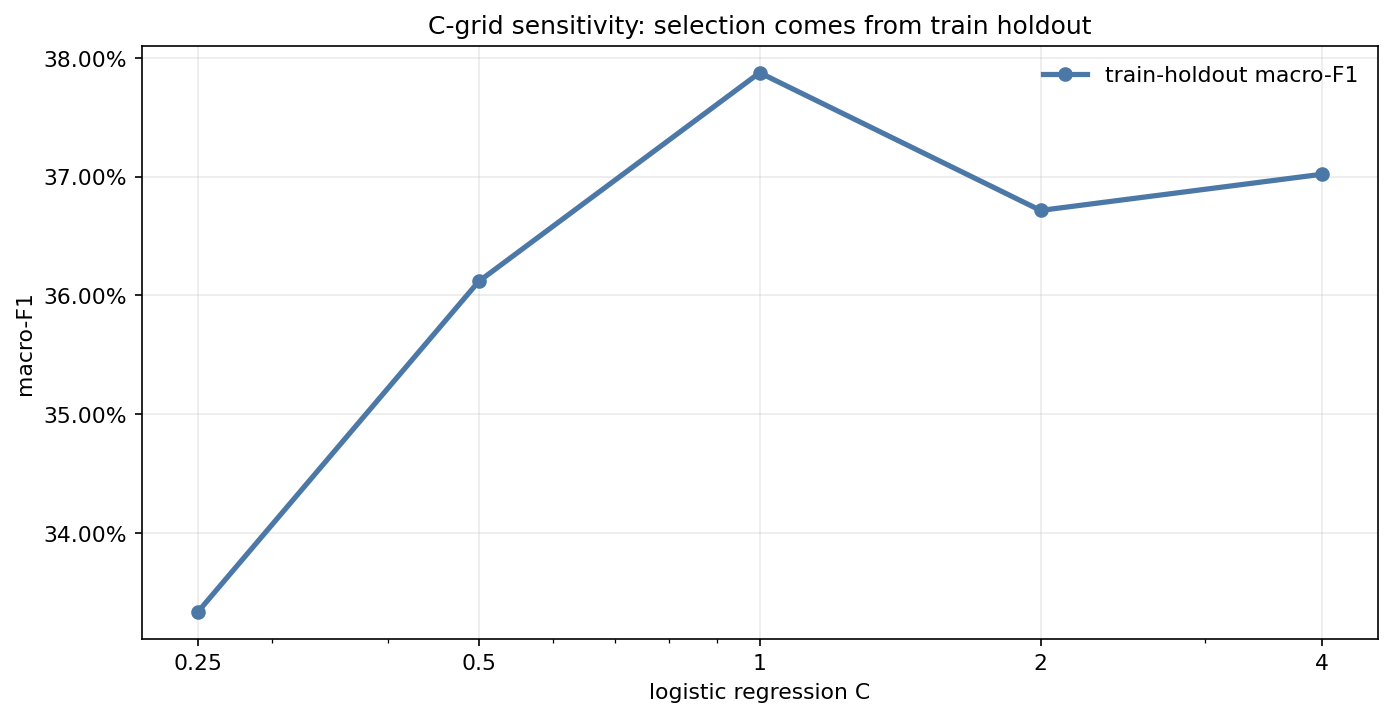

In [12]:
grid = load_json('round18/outputs/o_classifier/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000_tfidf_logreg_grid_search.json')
dev_rows = []
for row in grid['results']:
    cfg = row['config']
    if cfg['tfidf_max_features'] == 60000:
        dev_rows.append({'C': cfg['C'], 'macro_f1': row['macro_f1'], 'accuracy': row['accuracy']})
dev_rows.sort(key=lambda x: x['C'])

selection_rows = []
for row in grid['best']['selection_meta'].get('selection_results', []):
    cfg = row['selection_config']
    if cfg['tfidf_max_features'] == 60000:
        selection_rows.append({'C': cfg['C'], 'macro_f1': row['macro_f1'], 'accuracy': row['accuracy']})
selection_rows.sort(key=lambda x: x['C'])

fig, ax = plt.subplots(figsize=(9.4, 4.9))
ax.plot([r['C'] for r in selection_rows], [r['macro_f1'] for r in selection_rows], marker='o', lw=2.5, color=method_color('Promoted logreg classifier'), label='train-holdout macro-F1')
ax.set_xscale('log')
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_title('C-grid sensitivity: selection comes from train holdout')
ax.set_xlabel('logistic regression C')
ax.set_ylabel('macro-F1')
ax.legend(loc='best')
fig.tight_layout()
savefig('round18_revised_classifier_c_grid_curve.png')
plt.show()


# 10. Final Results

The final cell is the only place where the tutorial uses a confusion matrix. The bar chart is appropriate here because it compares strict classifier outputs at fixed operating points.


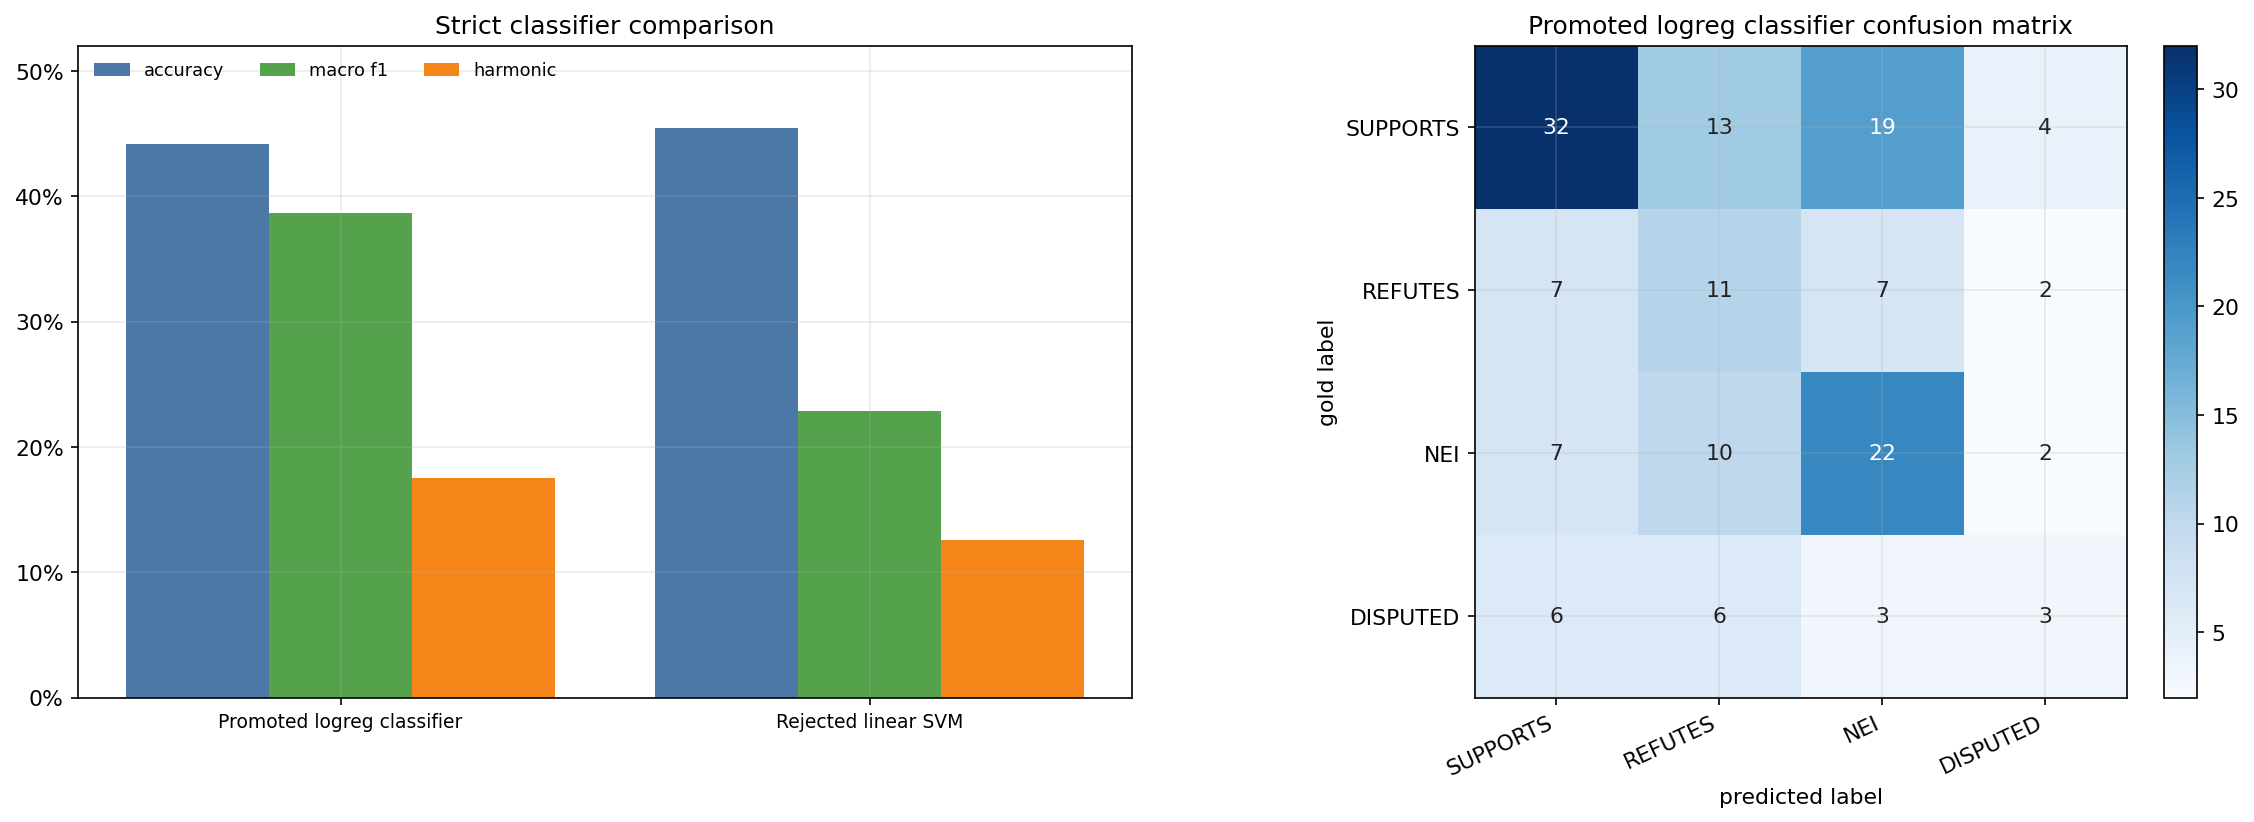

In [13]:
final_paths = {
    'Promoted logreg classifier': 'round18/outputs/o_classifier/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000_tfidf_logreg_mf60000_ngram1x2_c1p0_metrics.json',
    'Rejected linear SVM': 'round18/outputs/o_classifier/o_c3_strict_context_bm25_char_rrf_top1000/o_c3_strict_context_bm25_char_rrf_top1000_linear_svm_mf30000_ngram1x2_c0p25_metrics.json',
}
final_rows = []
for label, path in final_paths.items():
    m = load_json(path)
    final_rows.append({
        'label': label,
        'accuracy': m.get('accuracy', m.get('claim_accuracy')),
        'macro_f1': m.get('macro_f1', m.get('claim_macro_f1')),
        'harmonic': m.get('harmonic_mean_F_A', m.get('harmonic_mean_F_A')),
    })

def load_confusion(path):
    rows = []
    with (ROOT / path).open('r', encoding='utf-8', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)[1:]
        for row in reader:
            rows.append([int(x) for x in row[1:]])
    return header, np.array(rows)

conf_labels, conf = load_confusion('round18/outputs/o_classifier/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000/o_c3_context_k5_grid_logreg_bm25_char_rrf_top1000_tfidf_logreg_mf60000_ngram1x2_c1p0_confusion_matrix.csv')

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15.2, 5.6), gridspec_kw={'width_ratios': [1.12, 1.0]})
x = np.arange(len(final_rows))
width = 0.27
for offset, key, color in [(-width, 'accuracy', COLORS['blue']), (0, 'macro_f1', COLORS['green']), (width, 'harmonic', COLORS['orange'])]:
    vals = [row[key] for row in final_rows]
    ax0.bar(x + offset, vals, width=width, label=key.replace('_', ' '), color=color)
ax0.set_xticks(x)
ax0.set_xticklabels([row['label'] for row in final_rows], fontsize=9)
ax0.yaxis.set_major_formatter(PERCENT)
ax0.set_ylim(0, 0.52)
ax0.set_title('Strict classifier comparison')
ax0.legend(loc='upper left', ncol=3, fontsize=8.5)

im = ax1.imshow(conf, cmap='Blues')
ax1.set_xticks(np.arange(len(conf_labels)))
ax1.set_yticks(np.arange(len(LABEL_ORDER)))
ax1.set_xticklabels([LABEL_DISPLAY.get(x, x) for x in conf_labels], rotation=25, ha='right')
ax1.set_yticklabels([LABEL_DISPLAY[x] for x in LABEL_ORDER])
ax1.set_xlabel('predicted label')
ax1.set_ylabel('gold label')
ax1.set_title('Promoted logreg classifier confusion matrix')
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax1.text(j, i, str(conf[i, j]), ha='center', va='center', color='white' if conf[i, j] > conf.max() * 0.55 else '#222222')
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
fig.tight_layout()
savefig('round18_revised_final_bar_and_confusion.png')
plt.show()
